# Licenciatura en Ciencia de Datos
## Calidad y Preprocesamiento de Datos

---

### **Proyecto Final:**

**Equipo**

 **Castrillo Cruz Karen Arlet**

 **Pérez Aguiar Oropeza Gabriel Emiliano**

 **Ramos González Nadia**

 **Rueda Reyes Fabian**

 **Torres Pasión Angel Isaac**


* **Fecha de entrega:** 27 de mayo de 2026
* **Profesor: Victor Manuel Corza Vargas**

### **Objetivo**
Producir una versión completa, limpia y deduplicada del Registro Nacional de Personas Sancionadas del INE, utilizando la base de datos de personas agresoras del BANAVIM (Banco Nacional de Datos e Información sobre Casos de Violencia contra las Mujeres) como fuente auxiliar de enriquecimiento demográfico.
El resultado final nos dará el registro dorado de cada agresor en el micrositio del INE.

### **Fuentes**
| Base | Registros | Nombres | Uso en el proyecto |
|---|---|---|---|
| **INE** | 530 | Sí (503 no nulos) | Fuente principal |
| **BANAVIM 2020** | 260,341 | No (anónima) | Fuente auxiliar |
| **BANAVIM 2021** | 278,636 | No (anónima) | Fuente auxiliar |
| **BANAVIM 2022** | 247,749 | No (anónima) | Fuente auxiliar |

## 0. Bibliotecas necesarias

In [1]:
!pip install recordlinkage fuzzywuzzy python-Levenshtein jellyfish unidecode networkx ydata-profiling --quiet

In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import pickle
import json as _json

import jellyfish
from unidecode import unidecode
import recordlinkage
import networkx as nx
from unicodedata import normalize
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from ydata_profiling import ProfileReport

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style='whitegrid')

print('Entorno listo')

Entorno listo


## 1. Ingesta de Datos

In [3]:
# 1.1 INE — Registro Nacional de Personas Sancionadas
df_ine_raw = pd.read_excel(r'C:\Users\terri\OneDrive\Documentos\GitHub\Calidad-y-Preprocesamiento-de-Datos---Registro-Publico-de-Agresores\Data\Registro-nacional-de-personas-sancionadas (INE).xlsx')
df_ine_raw.columns = df_ine_raw.columns.str.strip()
print(f'INE crudo: {df_ine_raw.shape}')

# 1.2 BANAVIM por año — hoja AGRESORES
# Cada archivo tiene dos hojas: 'CASOS YYYY' y 'AGRESORES YYYY'.
# La fila 0 del Excel contiene los nombres de columna reales.
def leer_banavim_agresores(path: str, año: int) -> pd.DataFrame:
    sheet = f'AGRESORES {año}'
    df = pd.read_excel(path, sheet_name=sheet, header=0)
    df.columns = df.iloc[0]          # fila 0 = headers reales
    df = df.drop(index=0).reset_index(drop=True)
    df.columns = df.columns.str.strip()
    df['año_base'] = año
    return df


#Leído en pkl para evitar parsear miles de líneas

# bv_2020 = leer_banavim_agresores('../Data/2020.xlsx', 2020)
# bv_2021 = leer_banavim_agresores('../Data/2021.xlsx', 2021)
# bv_2022 = leer_banavim_agresores('../Data/2022.xlsx', 2022)

with open(r'C:\Users\terri\OneDrive\Documentos\GitHub\Calidad-y-Preprocesamiento-de-Datos---Registro-Publico-de-Agresores\Código\bv_2020.pkl', 'rb') as f:
    bv_2020 = pickle.load(f)

with open(r'C:\Users\terri\OneDrive\Documentos\GitHub\Calidad-y-Preprocesamiento-de-Datos---Registro-Publico-de-Agresores\Código\bv_2021.pkl', 'rb') as f:
    bv_2021 = pickle.load(f)

with open(r'C:\Users\terri\OneDrive\Documentos\GitHub\Calidad-y-Preprocesamiento-de-Datos---Registro-Publico-de-Agresores\Código\bv_2022.pkl', 'rb') as f:
    bv_2022 = pickle.load(f)

print(f'BANAVIM AGRESORES 2020: {bv_2020.shape}')
print(f'BANAVIM AGRESORES 2021: {bv_2021.shape}')
print(f'BANAVIM AGRESORES 2022: {bv_2022.shape}')


INE crudo: (530, 25)
BANAVIM AGRESORES 2020: (265760, 28)
BANAVIM AGRESORES 2021: (285984, 28)
BANAVIM AGRESORES 2022: (254348, 28)


In [4]:
# Vista previa
df_ine_raw.tail(5)

,Nombre,"Calidad, cargo o profesión del sujeto infractor",Sexo,Ámbito Territorial,Entidad Federativa,Municipio,Número De Expediente,Relación Con La Víctima,Incidencia,Órgano Resolutor,Fecha De La Resolución,Conducta,Sanción,Permanencia,Reincidencia De La Conducta,Resolución Penal,Analizó Modo Honesto De Vivir,Cumple Modo Honesto De Vivir,Perteneciente a,Documento Enlace,Enlace Utce Temporalidad,Interseccion de la víctima,Tipo de violencia,Modalidad de violencia,Medidas de reparacion
525,YOLANDA ADELAIDA SANTOS MONTAÑO,NaN,Mujer,Municipal,Oaxaca,San Jacinto Amilpas,JDC/133/2020,Pares,No aplica,TE,11/06/2021,"Negativa a restituir a la víctima en el pleno goce de sus derechos políticos electorales, al omi...",Ninguna,29/09/2027,Sí,No,Sí,No,NaN,https://repositoriodocumental.ine.mx/xmlui/bitstream/handle/123456789/131519/JDC-133-2020-TEEO.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>No lo precisa</element>_x000d_\n...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>Medidas de no repetición</e..."
526,YOLANDA ADELAIDA SANTOS MONTAÑO,NaN,Mujer,Municipal,Oaxaca,San Jacinto Amilpas,JDC/143/2020,Pares,No aplica,TE,11/06/2021,Omisión de pago de dietas a la víctima y de convocarla a sesiones de cabildo,Ninguna,29/09/2027,Sí,No,Sí,No,NaN,https://repositoriodocumental.ine.mx/xmlui/bitstream/handle/123456789/131520/JDC-143-2020-TEEO.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>No lo precisa</element>_x000d_\n...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>Medidas de no repetición</e..."
527,YOLANDA ADELAIDA SANTOS MONTAÑO,NaN,Mujer,Municipal,Oaxaca,San Jacinto Amilpas,SUP-REC-117/2022,Pares,"Pérdida del modo honesto de vivir para los próximos procesos electorales federales, locales y mu...",TEPJF SS,04/05/2022,Revictimización derivada del incumplimiento de las medidas ordenadas ante la existencia de la VP...,Perdida del modo honesto de vivir,05/05/2028,Sí,No,Sí,No,NaN,https://repositoriodocumental.ine.mx/xmlui/bitstream/handle/123456789/134552/SUP-REC-117-2022.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>No lo precisa</element>_x000d_\n...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>No impone</element>_x000d_\..."
528,YOSHIO CÉSAR RAMÍREZ CASTILLO,NaN,Hombre,Municipal,Oaxaca,Ocotlán de Morelos,JDC/05/2024 Y JDC/96/2024 ACUMULADOS,Pares,No aplica,TE,20/09/2024,"Conducta consistente en limitar el acceso a la información financiera, además de no proporcionar...",Amonestación pública,2029-06-04T00:00:00,No,No,No,NaN,NaN,https://teeo.mx/images/sentencias/JDC-05-2024-1.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>Verbal</element>_x000d_\n <elem...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>Disculpa pública</element>_..."
529,YURIDIA PINEDA ORDAZ,NaN,Mujer,Municipal,Oaxaca,El Espinal,JDC/797/2022,Pares,No aplica,TE,08/02/2023,"Invisibilizar a la víctima al limitarla de proporcionarle materiales de oficina, documentación y...",Ninguna,2029-06-01T00:00:00,Sí,No,Sí,Sí,NaN,https://teeo.mx/images/sentencias/JDC-797-2022.pdf,NaN,NaN,"tipo_conducta type=""Collection(Edm.String)"">_x000d_\n <element>Psicológica</element>_x000d_\n ...",NaN,"medidas_reparacion type=""Collection(Edm.String)"">_x000d_\n <element>Disculpa pública</element>_..."


In [5]:
print('BANAVIM AGRESORES 2020')
display(bv_2020.head(3))
print('BANAVIM AGRESORES 2021')
display(bv_2021.tail(3))
print('BANAVIM AGRESORES 2022')
display(bv_2022.tail(3))

BANAVIM AGRESORES 2020


,Identificador Único,Edad del Agresor,Sexo,Escolaridad,Estado Civil,Fecha de registro,Estado donde reside,Municipio donde reside,Relación o vículo con la víctima,Conoce al Agresor,Durante la agresión efectos droga,Cual Droga,Droga_Alcohol,Droga_DrogaPorIndicación Médica,Droga_Drogas Ilegales,La Consume Manera Cotidiana,Posee_algun tipo de arma,Portaba Dicha Arma,Chacos,Macanas,OtraArmaBlanca,ObjetoPunzoCortante,Machete,Proyectil,ArmaFuegoCorta,ArmaFuegoLarga,OtraFuegoLarga,año_base
0,0128900022-2,34,Hombre,No identificado,NaN,2020-09-03 08:59:29,Aguascalientes,Aguascalientes,Ex pareja,SI,SE DESCONOCE,NaN,0,0,0,NaN,SE DESCONOCE,NaN,0,0,0,0,0,0,0,0,0,2020
1,0128900106-2,50,Hombre,No identificado,NaN,2020-10-20 09:25:05,Aguascalientes,Aguascalientes,CÃ³nyuge o pareja,SI,SE DESCONOCE,NaN,0,0,0,NaN,SE DESCONOCE,NaN,0,0,0,0,0,0,0,0,0,2020
2,0128900132-2,58,Hombre,No identificado,UniÃ³n libre,2020-07-02 08:07:24,Aguascalientes,Aguascalientes,CÃ³nyuge o pareja,SI,SE DESCONOCE,NaN,0,0,0,NaN,SE DESCONOCE,NaN,0,0,0,0,0,0,0,0,0,2020


BANAVIM AGRESORES 2021


,Identificador Único,Edad del Agresor,Sexo,Escolaridad,Estado Civil,Fecha de registro,Estado donde reside,Municipio donde reside,Relación o vículo con la víctima,Conoce al Agresor,Durante la agresión efectos droga,Cual Droga,Droga_Alcohol,Droga_DrogaPorIndicación Médica,Droga_Drogas Ilegales,La Consume Manera Cotidiana,Posee_algun tipo de arma,Portaba Dicha Arma,Chacos,Macanas,OtraArmaBlanca,ObjetoPunzoCortante,Machete,Proyectil,ArmaFuegoCorta,ArmaFuegoLarga,OtraFuegoLarga,año_base
285981,743509007 -3,40,Hombre,Primaria,UniÃ³n libre,2021-11-05 10:11:20,Chiapas,Tuxtla GutiÃ©rrez,CÃ³nyuge o pareja,SI,SI,Alcohol,1,0,1,SE DESCONOCE,SE DESCONOCE,NaN,0,0,0,0,0,0,0,0,0,2021
285982,743509007 -3,40,Hombre,Primaria,UniÃ³n libre,2021-11-05 10:11:20,Chiapas,Tuxtla GutiÃ©rrez,CÃ³nyuge o pareja,SI,SI,Drogas ilegales,1,0,1,SE DESCONOCE,SE DESCONOCE,NaN,0,0,0,0,0,0,0,0,0,2021
285983,743509127 -2,34,Hombre,Primaria,NaN,2021-04-16 12:56:58,Chiapas,Tuxtla GutiÃ©rrez,Seleccione,SI,SE DESCONOCE,NaN,0,0,0,NaN,SE DESCONOCE,NaN,0,0,0,0,0,0,0,0,0,2021


BANAVIM AGRESORES 2022


,Identificador Único,Edad del Agresor,Sexo,Escolaridad,Estado Civil,Fecha de registro,Estado donde reside,Municipio donde reside,Relación o vículo con la víctima,Conoce al Agresor,Durante la agresión efectos droga,Cual Droga,Droga_Alcohol,Droga_DrogaPorIndicación Médica,Droga_Drogas Ilegales,La Consume Manera Cotidiana,Posee_algun tipo de arma,Portaba Dicha Arma,Chacos,Macanas,OtraArmaBlanca,ObjetoPunzoCortante,Machete,Proyectil,ArmaFuegoCorta,ArmaFuegoLarga,OtraFuegoLarga,año_base
254345,743508856 -3,27,Hombre,No identificado,Concubinato,2022-09-19 11:17:25,Chiapas,San CristÃ³bal de las Casas,CÃ³nyuge o pareja,SI,SE DESCONOCE,NaN,0,0,0,NaN,SI,SI,0,0,0,0,0,0,1,0,0,2022
254346,743508884 -2,35,Hombre,Primaria,UniÃ³n libre,2022-09-17 16:42:24,Chiapas,Tapachula,CÃ³nyuge o pareja,SI,NO,NaN,0,0,0,NaN,NO,NaN,0,0,0,0,0,0,0,0,0,2022
254347,743508892 -2,18,Hombre,No identificado,Soltero,2022-03-01 16:56:51,Quintana Roo,Benito JuÃ¡rez,Hijo(a),SI,NO,NaN,0,0,0,NaN,NO,NaN,0,0,0,0,0,0,0,0,0,2022


## 2. Análisis Exploratorio de los Datos

Exploramos los datos crudos antes de cualquier transformación.


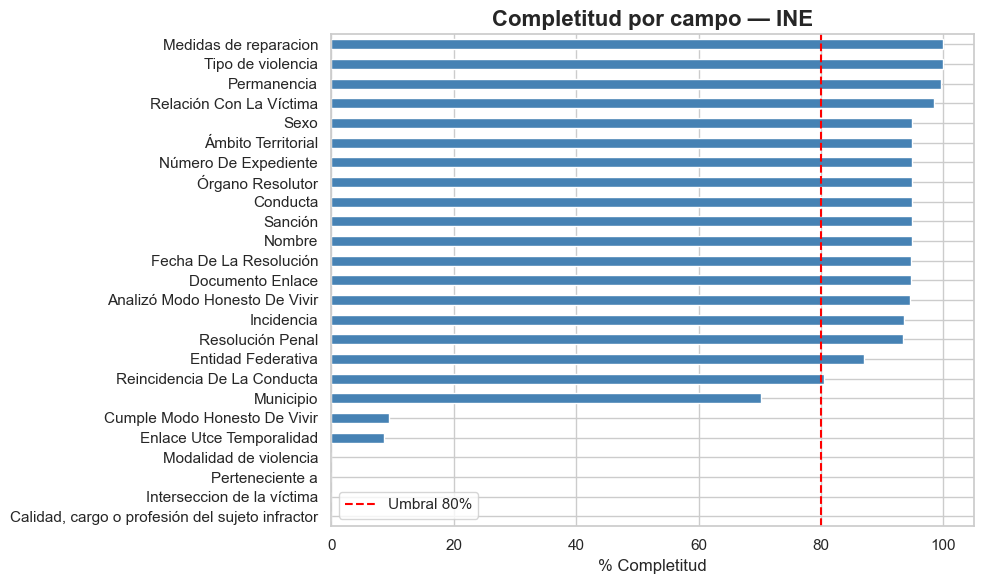

Calidad, cargo o profesión del sujeto infractor      0.0
Interseccion de la víctima                           0.0
Perteneciente a                                      0.0
Modalidad de violencia                               0.0
Enlace Utce Temporalidad                             8.7
Cumple Modo Honesto De Vivir                         9.4
Municipio                                           70.2
Reincidencia De La Conducta                         80.6
Entidad Federativa                                  87.0
Resolución Penal                                    93.4
Incidencia                                          93.6
Analizó Modo Honesto De Vivir                       94.5
Documento Enlace                                    94.7
Fecha De La Resolución                              94.7
Nombre                                              94.9
Sanción                                             94.9
Conducta                                            94.9
Órgano Resolutor               

In [6]:
# 2.1 Completitud INE
completitud_ine = (1 - df_ine_raw.isnull().mean()) * 100

fig, ax = plt.subplots(figsize=(10, 6))
completitud_ine.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(80, color='red', ls='--', label='Umbral 80%')
ax.set_xlabel('% Completitud')
ax.set_title('Completitud por campo — INE', fontsize=16, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(completitud_ine.sort_values().round(1).to_string())

In [7]:
# 2.2 Duplicados exactos por Nombre
dup_nombres = df_ine_raw[
    df_ine_raw['Nombre'].notna() &
    df_ine_raw['Nombre'].duplicated(keep=False)
]
print(f'Registros con nombres duplicados: {len(dup_nombres)}')
display(
    dup_nombres.sort_values('Nombre')[
        ['Nombre','Número De Expediente','Conducta','Fecha De La Resolución']
    ].head(15)
)

Registros con nombres duplicados: 74


,Nombre,Número De Expediente,Conducta,Fecha De La Resolución
46,ALEJANDRO GARCÍA HERNÁNDEZ,TEV-JDC-7/2025,Conductas encaminadas a entorpecer y demeritar su participación en el ejercicio del cargo de la ...,19/02/2025
47,ALEJANDRO GARCÍA HERNÁNDEZ,TEV-PES-25/2025,"Conductas desplegadas por el infractor al negar la contratación de un auxiliar, así como apoyo j...",10/06/2025
48,ALEJANDRO GARCÍA HERNÁNDEZ,TEV-PES-97/2025,Manifestaciones realizadas en publicaciones con la intención de disminuir las capacidades de la ...,25/02/2026
49,ALEJANDRO GARCÍA HERNÁNDEZ,TEV-PES-258/2025,"Actos que invisibilizan y discriminan a la quejosa, consistentes en la negativa de proporcionarl...",19/03/2026
55,ALEJANDRO SEVILLA TORRES,TEE-PES-60/2024,Publicaciones realizadas en la red social Facebook con la finalidad de desacredita y denigrar a ...,08/05/2025
56,ALEJANDRO SEVILLA TORRES,CLE-POS-022/2019,Publicaciones realizadas en la red social Facebook y en periódicos que utilizan estereotipos dir...,06/05/2021
103,CARLOS MARIO CORNELIO CORNELIO,PES/075/2021,Obstaculizar la entrega de licencia para la separación del cargo de delegada municipal para que ...,31/03/2022
104,CARLOS MARIO CORNELIO CORNELIO,PES/078/2021,Obstaculizar la entrega de licencia para la separación del cargo de delegada municipal para part...,28/02/2022
115,DANIEL LÓPEZ PLATAS,JDCI/48/2024,Acciones y omisiones que tuvieron como efecto directo el menoscabo del ejercicio del cargo de la...,03/12/2024
116,DANIEL LÓPEZ PLATAS,JDCI/73/2023,"Omisión de convocar a la víctima a sesiones de cabildo, obstaculizando su entrada a las oficinas...",20/10/2023


In [8]:
# 2.3 Campos con formatos mixtos
# 'Permanencia', 'Tipo de violencia' y 'Medidas de reparacion'
print('Permanencia (top 10 valores)\n')
print(df_ine_raw['Permanencia'].value_counts().head(10).to_string())
print()
print('Tipo de violencia (primeros 3 valores unicos)\n')
for v in df_ine_raw['Tipo de violencia'].dropna().unique()[:3]:
    print(' ', v[:120])
print()
print('Medidas de reparacion (primeros 3 valores unicos)\n')
for v in df_ine_raw['Medidas de reparacion'].dropna().unique()[:3]:
    print(' ', v[:120])

Permanencia (top 10 valores)

Permanencia
Indeterminada          26
07/10/2027             11
2026-10-11T00:00:00    10
15/07/2026              9
2027-03-25T00:00:00     8
2026-09-13T00:00:00     7
20/07/2028              7
25/06/2026              6
2026-07-09T00:00:00     6
2026-07-27T00:00:00     6

Tipo de violencia (primeros 3 valores unicos)

  tipo_conducta null="true"></tipo_conducta
  tipo_conducta type="Collection(Edm.String)">_x000d_
  <element>Simbólica</element>_x000d_
</tipo_conducta
  tipo_conducta type="Collection(Edm.String)">_x000d_
  <element>Simbólica</element>_x000d_
  <element>Psicológica</elemen

Medidas de reparacion (primeros 3 valores unicos)

  medidas_reparacion null="true"></medidas_reparacion
  medidas_reparacion type="Collection(Edm.String)">_x000d_
  <element>Medidas de satisfacción, medidas de restitución</ele
  medidas_reparacion type="Collection(Edm.String)">_x000d_
  <element>Medidas de no repetición</element>_x000d_
  <element


In [9]:
# 2.4 Distribuciones en campos categoricos

print('Campos categoricos con posibles inconsistencias (Top 7):')
for col in ['Sexo', 'Ambito Territorial', 'Sancion', 'Entidad Federativa']:
    col_real = next((c for c in df_ine_raw.columns if c.strip() == col or
                     unidecode(c.strip()) == unidecode(col)), None)
    if col_real:
        print(f'')
        conteo = df_ine_raw[col_real].value_counts(dropna=False)

        print(conteo.head(7).to_string())

        if len(conteo) > 7:
            print(f'... y {len(conteo) - 7} categorias mas ocultas.')

Campos categoricos con posibles inconsistencias (Top 7):

Sexo
Hombre    412
Mujer      91
NaN        27

Ámbito Territorial
Municipal    340
Estatal       86
Nacional      77
NaN           27

Sanción
Ninguna                           228
Multa económica                   144
Amonestación pública              100
NaN                                27
Inscripción en el RNPS             25
Multa, prisión y  amonestación      1
Multa simbólica                     1
... y 4 categorias mas ocultas.

Entidad Federativa
Oaxaca              143
Veracruz             72
NaN                  69
Chiapas              37
Tabasco              26
Estado de México     22
Guanajuato           20
... y 23 categorias mas ocultas.


Fecha minima: 2020-11-09 00:00:00 | Fecha maxima: 2026-04-29 00:00:00
Fechas no parseables: 42


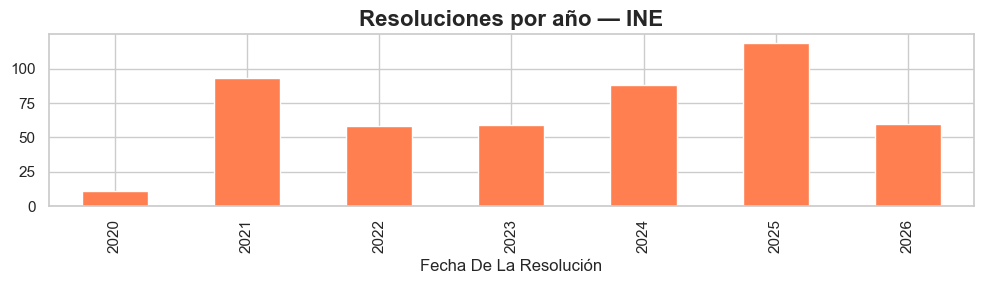

In [10]:
# 2.5 Oportunidad: resoluciones por año
fechas = pd.to_datetime(df_ine_raw['Fecha De La Resolución'], dayfirst=True, errors='coerce')
print(f'Fecha minima: {fechas.min()} | Fecha maxima: {fechas.max()}')
print(f'Fechas no parseables: {fechas.isna().sum()}')

fechas.dropna().dt.year.value_counts().sort_index().plot(
    kind='bar', figsize=(10, 3), color='coral'
)
plt.title('Resoluciones por año — INE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

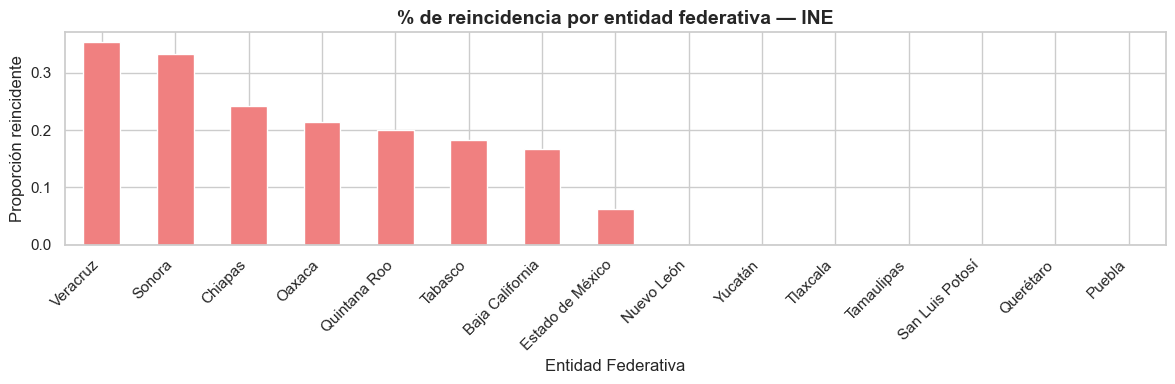

In [11]:
# 2.6 Reincidencia por entidad federativa
reincidencia = (
    df_ine_raw[df_ine_raw['Reincidencia De La Conducta'].notna()]
    .groupby('Entidad Federativa')['Reincidencia De La Conducta']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
# Solo columna 'Sí' si existe
col_si = [c for c in reincidencia.columns if str(c).strip().lower() in ('sí','si','yes','1','true')]
if col_si:
    reincidencia[col_si[0]].sort_values(ascending=False).head(15).plot(
        kind='bar', figsize=(12, 4), color='lightcoral', edgecolor='white'
    )
    plt.title('% de reincidencia por entidad federativa — INE', fontsize=14, fontweight='bold')
    plt.ylabel('Proporción reincidente')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Valores únicos en Reincidencia De La Conducta:')
    print(df_ine_raw['Reincidencia De La Conducta'].value_counts(dropna=False))


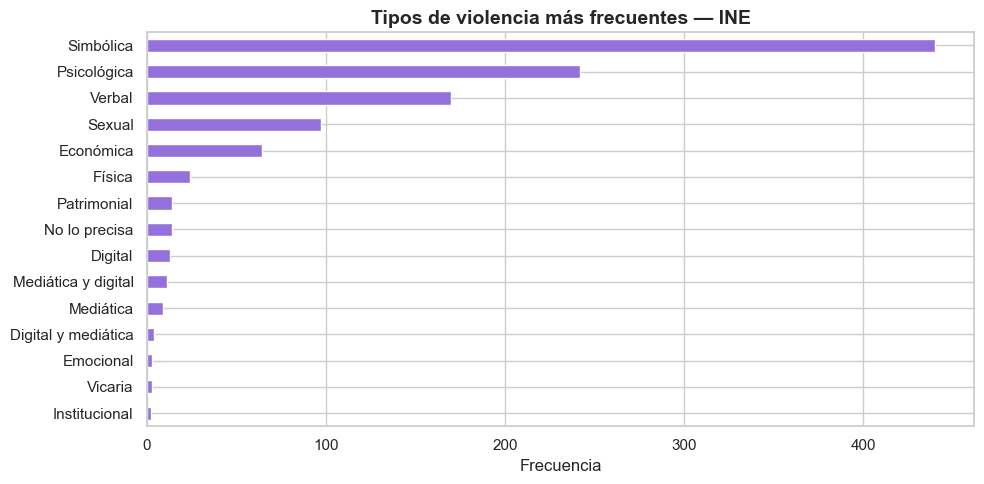

In [12]:
# 2.7 Tipos de violencia más frecuentes (tras parsear el XML)
tipos_raw = df_ine_raw['Tipo de violencia'].dropna()
todos_tipos = []
for val in tipos_raw:
    elementos = re.findall(r'<element>([^<]+)</element>', str(val))
    todos_tipos.extend([e.strip() for e in elementos])

if todos_tipos:
    pd.Series(todos_tipos).value_counts().head(15).sort_values().plot(
        kind='barh', figsize=(10, 5), color='mediumpurple', edgecolor='white'
    )
    plt.title('Tipos de violencia más frecuentes — INE', fontsize=14, fontweight='bold')
    plt.xlabel('Frecuencia')
    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron etiquetas <element> en Tipo de violencia')


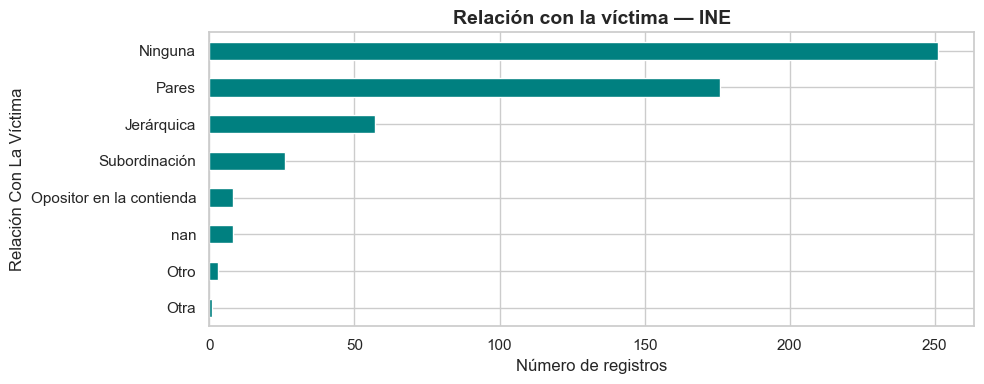

In [13]:
# 2.8 Relación víctima-agresor
fig, ax = plt.subplots(figsize=(10, 4))
(
    df_ine_raw['Relación Con La Víctima']
    .value_counts(dropna=False)
    .head(12)
    .sort_values()
    .plot(kind='barh', ax=ax, color='teal', edgecolor='white')
)
ax.set_title('Relación con la víctima — INE', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de registros')
plt.tight_layout()
plt.show()


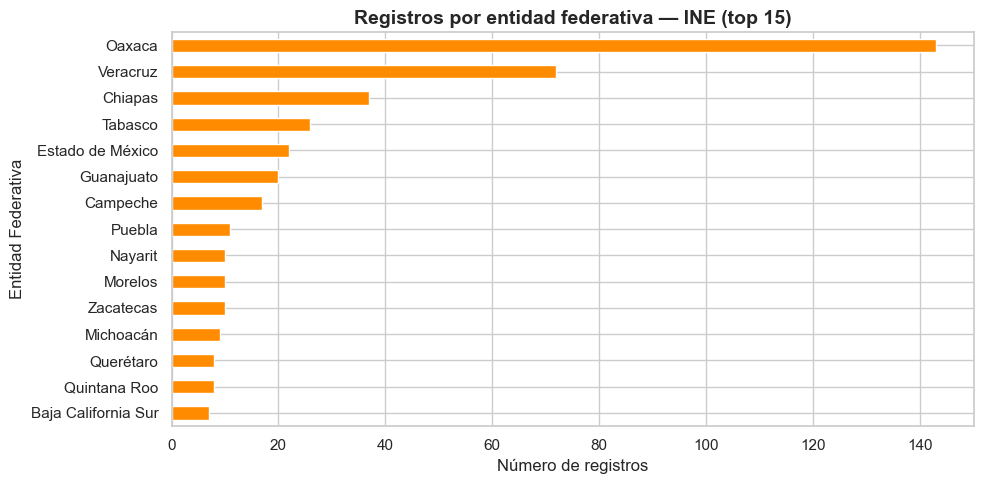

In [14]:
# 2.9 Agresores por entidad federativa (top 15)
fig, ax = plt.subplots(figsize=(10, 5))
(
    df_ine_raw['Entidad Federativa']
    .value_counts()
    .head(15)
    .sort_values()
    .plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
)
ax.set_title('Registros por entidad federativa — INE (top 15)', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de registros')
plt.tight_layout()
plt.show()


## 3. Limpieza y normalizacion

In [15]:
# 3.1 Funciones de normalización

MAPA_ESTADOS = {
    'CIUDAD DE MEXICO': 'CDMX',
    'D.F.': 'CDMX',
    'MEXICO': 'ESTADO DE MEXICO',
    'EDO MEX': 'ESTADO DE MEXICO',
    'VERACRUZ DE IGNACIO DE LA LLAVE': 'VERACRUZ',
    'MICHOACAN DE OCAMPO': 'MICHOACAN',
    'COAHUILA DE ZARAGOZA': 'COAHUILA'
}

def normalizar_nombre(texto):
    """Minúsculas, sin acentos, sin puntuación, espacios colapsados.
    Devuelve None si el valor original era nulo o solo espacios."""
    if pd.isna(texto) or not str(texto).strip():
        return None          # <-- None, no ''
    t = unidecode(str(texto)).lower()
    t = re.sub(r'[^a-z\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t if t else None  # <-- None si tras limpiar queda vacío

def nombre_canonico(texto):
    """Tokens ordenados alfabéticamente — clave para bloqueo exacto."""
    norm = normalizar_nombre(texto)
    if norm is None:
        return None
    return ' '.join(sorted(norm.split()))

def normalizar_estado(estado):
    """Devuelve None si el valor original era nulo."""
    if pd.isna(estado) or not str(estado).strip():
        return None          # <-- None, no ''
    e = unidecode(str(estado)).upper().strip()
    return MAPA_ESTADOS.get(e, e)

def parsear_fecha(valor):
    """Maneja 'DD/MM/YYYY', 'YYYY-MM-DDT...' e 'Indeterminada'."""
    if pd.isna(valor) or str(valor).strip().lower() == 'indeterminada':
        return pd.NaT
    for fmt in ('%d/%m/%Y', '%Y-%m-%dT%H:%M:%S'):
        try:
            return pd.to_datetime(str(valor), format=fmt)
        except ValueError:
            pass
    return pd.to_datetime(valor, errors='coerce', dayfirst=True)

def extraer_xml_lista(texto):
    """Extrae valores de <element> en campos XML crudos del INE.
    Devuelve None si no hay contenido (no ''), para preservar los NaN."""
    if pd.isna(texto) or not str(texto).strip():
        return None          # <-- None, no ''
    elementos = re.findall(r'<element>([^<]+)</element>', str(texto))
    if not elementos:
        return None          # <-- None si no encontró tags (campo vacío o sin XML)
    return ' | '.join(e.strip() for e in elementos)

print('Funciones de normalización definidas')


Funciones de normalización definidas


In [16]:
# 3.2 Aplicar limpieza al INE
ine = df_ine_raw.copy()
ine.columns = ine.columns.str.strip()

ine['nombre']            = ine['Nombre'].apply(normalizar_nombre)
ine['entidad']           = ine['Entidad Federativa'].apply(normalizar_estado)
ine['fecha_resolucion']  = ine['Fecha De La Resolución'].apply(parsear_fecha)
ine['permanencia_fecha'] = ine['Permanencia'].apply(parsear_fecha)
ine['tipo_violencia']    = ine['Tipo de violencia'].apply(extraer_xml_lista)
ine['medidas_reparacion']= ine['Medidas de reparacion'].apply(extraer_xml_lista)

print(f'INE limpio: {ine.shape}')
ine[['nombre', 'entidad', 'fecha_resolucion',
     'permanencia_fecha', 'medidas_reparacion', 'tipo_violencia']].tail(5)


INE limpio: (530, 31)


,nombre,entidad,fecha_resolucion,permanencia_fecha,medidas_reparacion,tipo_violencia
525,yolanda adelaida santos montano,OAXACA,2021-06-11,2027-09-29,Medidas de no repetición | Disculpa pública | Medida de rehabilitación | Medidas de satisfacción...,No lo precisa
526,yolanda adelaida santos montano,OAXACA,2021-06-11,2027-09-29,Medidas de no repetición | Disculpa pública | Medidas de rehabilitación | Medidas de satisfacción,No lo precisa
527,yolanda adelaida santos montano,OAXACA,2022-05-04,2028-05-05,No impone,No lo precisa
528,yoshio cesar ramirez castillo,OAXACA,2024-09-20,2029-06-04,Disculpa pública | Medidas de no repetición | Medidas de no rehabilitación,Verbal | Psicológica | Simbólica
529,yuridia pineda ordaz,OAXACA,2023-02-08,2029-06-01,Disculpa pública | Medidas de no repetición | Medidas de rehabilitación | Medidas de satisfacción,Psicológica | Simbólica


In [17]:
# 3.3 Seleccionamos sólo los registros del INE de 2020 a 2022
ine = ine[ine['fecha_resolucion'].dt.year.between(2020, 2022)].reset_index(drop=True)
print(f'Tamaño del dataset INE (2020-2022): {ine.shape}')

Tamaño del dataset INE (2020-2022): (162, 31)


In [18]:
# 3.4 Limpieza BANAVIM — hoja AGRESORES (2020-2022)
# Columnas disponibles en la hoja AGRESORES (distinto al schema de CASOS):
#   Identificador Único, Edad del Agresor, Sexo, Escolaridad, Estado Civil,
#   Fecha de registro, Estado donde reside, Municipio donde reside,
#   Relación o vículo con la víctima, Conoce al Agresor,
#   Durante la agresión efectos droga, flags de drogas y armas.

FLAGS_ARMAS  = ['Chacos','Macanas','OtraArmaBlanca','ObjetoPunzoCortante',
                'Machete','Proyectil','ArmaFuegoCorta','ArmaFuegoLarga','OtraFuegoLarga']
FLAGS_DROGAS = ['Droga_Alcohol','Droga_DrogaPorIndicación Médica','Droga_Drogas Ilegales']

def limpiar_bv_agresores(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza un DataFrame de la hoja AGRESORES al schema común."""
    df = df.copy()
    df['estado']          = df['Estado donde reside'].apply(normalizar_estado)
    df['municipio']       = df['Municipio donde reside'].astype(str).str.strip().replace({'nan': None})
    df['sexo']            = df['Sexo'].astype(str).str.strip().str.title().replace({'Nan': None, 'nan': None})
    df['edad']            = pd.to_numeric(df['Edad del Agresor'], errors='coerce')
    df['escolaridad']     = df['Escolaridad'].astype(str).str.strip().replace({'nan': None})
    df['estado_civil']    = df['Estado Civil'].astype(str).str.strip().replace({'nan': None})
    df['vinculo_victima'] = df['Relación o vículo con la víctima'].astype(str).str.strip().replace({'nan': None})
    df['fecha_registro']  = pd.to_datetime(df['Fecha de registro'], errors='coerce')
    # Flags numéricos: drogas y armas (vienen como object tras leer_banavim)
    for col in FLAGS_DROGAS + FLAGS_ARMAS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

bv_2020 = limpiar_bv_agresores(bv_2020)
bv_2021 = limpiar_bv_agresores(bv_2021)
bv_2022 = limpiar_bv_agresores(bv_2022)

# Concatenar los tres años en 'bv'
bv = pd.concat([bv_2020, bv_2021, bv_2022], ignore_index=True)

print(f'BANAVIM AGRESORES 2020 limpio : {bv_2020.shape}')
print(f'BANAVIM AGRESORES 2021 limpio : {bv_2021.shape}')
print(f'BANAVIM AGRESORES 2022 limpio : {bv_2022.shape}')
print(f'BANAVIM total (bv)            : {bv.shape}')
print()
print('Completitud de campos clave en bv:')
campos_clave = ['estado','municipio','sexo','edad','escolaridad','estado_civil','vinculo_victima']
print((1 - bv[campos_clave].isnull().mean()).mul(100).round(1).to_string())
print()
display(bv[campos_clave].head(5))


BANAVIM AGRESORES 2020 limpio : (265760, 36)
BANAVIM AGRESORES 2021 limpio : (285984, 36)
BANAVIM AGRESORES 2022 limpio : (254348, 36)
BANAVIM total (bv)            : (806092, 36)

Completitud de campos clave en bv:
0
estado             100.0
municipio          100.0
sexo                82.4
edad                82.1
escolaridad         83.2
estado_civil        49.9
vinculo_victima     83.8



,estado,municipio,sexo,edad,escolaridad,estado_civil,vinculo_victima
0,AGUASCALIENTES,Aguascalientes,Hombre,34.0,No identificado,None,Ex pareja
1,AGUASCALIENTES,Aguascalientes,Hombre,50.0,No identificado,None,CÃ³nyuge o pareja
2,AGUASCALIENTES,Aguascalientes,Hombre,58.0,No identificado,UniÃ³n libre,CÃ³nyuge o pareja
3,AGUASCALIENTES,Aguascalientes,Hombre,37.0,No identificado,None,Ex pareja
4,AGUASCALIENTES,CosÃ­o,Hombre,42.0,Secundaria,Casado,CÃ³nyuge o pareja


## 4. Fusión de Datos: registros duplicados por nombre

Los registros con el mismo nombre representan distintas faltas o reincidencias del mismo agresor registradas en expedientes separados.

La estrategia es agrupar por Nombre y producir un único registro por persona:

- **Campos invariantes** (Sexo, Entidad, Municipio)
- **Campos por incidencia** (Conducta, Sanción, Expediente, Fecha)
- **Campos derivados** → n_incidencias y es_reincidente.

In [19]:
# Terminamos de ajustar ine, borrando las columnas con menos del 20% de completitud
ine = ine.drop(columns=completitud_ine[completitud_ine < 20].index)
print(f'INE ajustado (columnas con >=20% completitud): {ine.shape}')
print('Columnas finales en INE:')
print(ine.columns.to_list())

INE ajustado (columnas con >=20% completitud): (162, 25)
Columnas finales en INE:
['Nombre', 'Sexo', 'Ámbito Territorial', 'Entidad Federativa', 'Municipio', 'Número De Expediente', 'Relación Con La Víctima', 'Incidencia', 'Órgano Resolutor', 'Fecha De La Resolución', 'Conducta', 'Sanción', 'Permanencia', 'Reincidencia De La Conducta', 'Resolución Penal', 'Analizó Modo Honesto De Vivir', 'Documento Enlace', 'Tipo de violencia', 'Medidas de reparacion', 'nombre', 'entidad', 'fecha_resolucion', 'permanencia_fecha', 'tipo_violencia', 'medidas_reparacion']


In [20]:
# Guardamos la base de datos ine de incidencias
ine.to_csv(
    "../Data/ine_incidencias_2020_2022.csv",
    index=False,
    encoding="utf-8-sig",
)
print(f'INE guardado: ../Data/ine_incidencias_2020_2022.csv')

INE guardado: ../Data/ine_incidencias_2020_2022.csv


In [21]:
# 4.1 Definir qué campos son invariantes y cuáles varían por incidencia

CAMPOS_INVARIANTES = [
    'Sexo',
    'Ámbito Territorial',
    'Entidad Federativa',
    'Municipio',
    'Relación Con La Víctima',
    'entidad',
    'nombre',
]

CAMPOS_POR_INCIDENCIA = [
    'Número De Expediente',
    'Incidencia',
    'Órgano Resolutor',
    'Conducta',
    'Sanción',
    'Permanencia',
    'Reincidencia De La Conducta',
    'Resolución Penal',
    'Analizó Modo Honesto De Vivir',
    'Cumple Modo Honesto De Vivir',
    'Documento Enlace',
    'Enlace Utce Temporalidad',
    'Modalidad de violencia',
    'fecha_resolucion',
    'permanencia_fecha',
    'tipo_violencia',
    'medidas_reparacion',
]

print(f'Campos invariantes    : {len(CAMPOS_INVARIANTES)}')
print(f'Campos por incidencia : {len(CAMPOS_POR_INCIDENCIA)}')

Campos invariantes    : 7
Campos por incidencia : 17


In [22]:
# 4.2 Función de consolidación

def consolidar_persona(df_grupo: pd.DataFrame) -> dict:
    """
    Recibe todas las filas de un mismo Nombre y devuelve un dict con:
    - Campos invariantes : valor único (moda; en empate, el más largo)
    - Campos por incidencia : lista Python ordenada por fecha_resolucion
    - Campos derivados  : n_incidencias, es_reincidente, uids_origen
    """
    # Ordenar incidencias cronológicamente antes de armar las listas
    df_grupo = df_grupo.sort_values('fecha_resolucion', na_position='last')

    gr = {}

    # Nombre representativo: el más largo del grupo
    gr['Nombre'] = max(df_grupo['Nombre'].dropna().tolist(),
                       key=lambda x: len(str(x)), default=None)

    # Campos invariantes
    for col in CAMPOS_INVARIANTES:
        if col not in df_grupo.columns:
            gr[col] = None
            continue
        vals = df_grupo[col].dropna()
        if len(vals) == 0:
            gr[col] = None
        else:
            moda = vals.mode()
            gr[col] = max(moda.tolist(), key=lambda x: len(str(x)))

    # Campos por incidencia → lista
    for col in CAMPOS_POR_INCIDENCIA:
        if col not in df_grupo.columns:
            gr[col] = []
            continue
        gr[col] = [None if pd.isna(v) else v for v in df_grupo[col].tolist()]

    # Campos derivados
    gr['n_incidencias']  = len(df_grupo)
    gr['es_reincidente'] = len(df_grupo) > 1

    return gr

print('Función consolidar_persona definida')


Función consolidar_persona definida


In [23]:
# 4.3 Aplicar consolidación
# Solo se agrupa por Nombre; registros sin nombre se conservan individualmente

ine_con_nombre    = ine[ine['Nombre'].notna()].copy()
ine_sin_nombre    = ine[ine['Nombre'].isna()].copy()

registros_golden = []
for nombre, df_grupo in ine_con_nombre.groupby('Nombre', sort=False):
    gr          = consolidar_persona(df_grupo)
    registros_golden.append(gr)

df_golden = pd.DataFrame(registros_golden)

print(f'Registros INE originales con nombre : {len(ine_con_nombre):,}')
print(f'Individuos únicos tras consolidación : {len(df_golden):,}')
print(f'Registros consolidados (reincidencias): {len(ine_con_nombre) - len(df_golden):,}')
print(f'Individuos reincidentes               : {df_golden["es_reincidente"].sum():,}')


Registros INE originales con nombre : 162
Individuos únicos tras consolidación : 140
Registros consolidados (reincidencias): 22
Individuos reincidentes               : 12


In [24]:
# 4.4 Vista previa de individuos reincidentes

display(
    df_golden[df_golden['es_reincidente']]
    [['Nombre', 'entidad', 'n_incidencias', 'Conducta', 'Sanción', 'fecha_resolucion']]
    .head(6)
)


,Nombre,entidad,n_incidencias,Conducta,Sanción,fecha_resolucion
25,CARLOS MARIO CORNELIO CORNELIO,TABASCO,2,[Obstaculizar la entrega de licencia para la separación del cargo de delegada municipal para par...,"[Multa económica, Multa económica]","[2022-02-28 00:00:00, 2022-03-31 00:00:00]"
28,DARWIN FÉLIX LÓPEZ,TABASCO,2,[Obstaculizar la entrega de licencia para separarse del cargo de delegada municipal para partici...,"[Multa económica, Multa económica]","[2022-02-28 00:00:00, 2022-03-31 00:00:00]"
36,ELÍ MARTÍNEZ LÓPEZ,OAXACA,2,[Conductas realizadas de manera sistemática dirigidas a sobajar a la actora de la oportunidad de...,"[Ninguna, Ninguna]","[2021-09-10 00:00:00, 2022-12-16 00:00:00]"
41,ERNESTO RUIZ FLANDES,VERACRUZ,10,[Conducta reiterada de convocar a la víctima a sesiones de cabildo sin la documentación completa...,"[Ninguna, Ninguna, Ninguna, Ninguna, Ninguna, Ninguna, Ninguna, Ninguna, Ninguna, Ninguna]","[2020-11-09 00:00:00, 2020-11-26 00:00:00, 2020-12-30 00:00:00, 2021-01-14 00:00:00, 2021-02-09 ..."
54,GILDARDO ZENTENO MORENO,CHIAPAS,2,[Reiteración y sistematización de la obstaculización e invisibilización del ejercicio del cargo ...,"[Ninguna, Ninguna]","[2021-05-01 00:00:00, 2021-11-10 00:00:00]"
57,HERMAS CORTÉS GARCÍA,VERACRUZ,2,"[Omisión de contestar diversos oficios, así como convocar a sesiones sin tomar en cuenta el esta...","[Amonestación pública, Ninguna]","[2021-03-03 00:00:00, 2021-05-12 00:00:00]"


In [25]:
# 4.5 Ejemplo detallado: persona con más incidencias
max_idx = df_golden['n_incidencias'].idxmax()
ej = df_golden.loc[max_idx]

print(f"Nombre      : {ej['Nombre']}")
print(f"Entidad     : {ej['entidad']}")
print(f"Incidencias : {ej['n_incidencias']}")
print()
for i, (cond, sanc, fecha) in enumerate(
    zip(ej['Conducta'], ej['Sanción'], ej['fecha_resolucion']), 1
):
    print(f'  [{i}] Fecha  : {fecha}')
    print(f'       Sanción : {sanc}')
    print(f'       Conducta: {str(cond)[:120]}')
    print()


Nombre      : ERNESTO RUIZ FLANDES
Entidad     : VERACRUZ
Incidencias : 10

  [1] Fecha  : 2020-11-09 00:00:00
       Sanción : Ninguna
       Conducta: Conducta reiterada de convocar a la víctima a sesiones de cabildo sin la documentación completa

  [2] Fecha  : 2020-11-26 00:00:00
       Sanción : Ninguna
       Conducta: Conducta reiterada de convocar a la víctima a sesiones de cabildo sin la documentación completa

  [3] Fecha  : 2020-12-30 00:00:00
       Sanción : Ninguna
       Conducta: Vulneración al derecho del ejercicio del cargo, al iniciar una sesión de Cabildo 15 minutos antes de la hora establecida

  [4] Fecha  : 2021-01-14 00:00:00
       Sanción : Ninguna
       Conducta: 1.-No se citó a la actora a las sesiones de cabildo con la documentación completa; 2.- Omisión de contestar peticiones d

  [5] Fecha  : 2021-02-09 00:00:00
       Sanción : Ninguna
       Conducta: Convocar a la víctima a sesiones sin la documentación correspondiente

  [6] Fecha  : 2021-04-13 00:0

## --- Resumen hasta aquí

In [26]:
# Resumen estructural de las bases disponibles hasta ahora
# Versión robusta para DataFrames con columnas tipo lista

def contar_duplicados_seguro(df):
    """
    Cuenta duplicados exactos incluso si hay columnas con listas/dicts.
    Convierte temporalmente valores no hashables a string.
    """
    try:
        return int(df.duplicated().sum())
    except TypeError:
        df_tmp = df.copy()
        for col in df_tmp.columns:
            df_tmp[col] = df_tmp[col].apply(
                lambda x: str(x) if isinstance(x, (list, dict, set)) else x
            )
        return int(df_tmp.duplicated().sum())


def resumen_base(nombre, df):
    return {
        "base": nombre,
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "celdas_totales": df.shape[0] * df.shape[1],
        "columnas_100_missing": int(df.isna().mean().eq(1).sum()),
        "columnas_con_missing": int(df.isna().any().sum()),
        "duplicados_exactos": contar_duplicados_seguro(df)
    }


bases_para_resumen = []

for nombre_variable, nombre_mostrar in [
    ("df_ine_raw", "INE crudo"),
    ("ine", "INE limpio / filtrado"),
    ("df_golden", "Registro golden INE"),
    ("bv_2020", "BANAVIM agresores 2020"),
    ("bv_2021", "BANAVIM agresores 2021"),
    ("bv_2022", "BANAVIM agresores 2022"),
    ("bv", "BANAVIM concatenado")
]:
    if nombre_variable in globals():
        bases_para_resumen.append(
            resumen_base(nombre_mostrar, globals()[nombre_variable])
        )

resumen_bases = pd.DataFrame(bases_para_resumen)

display(resumen_bases)

,base,filas,columnas,celdas_totales,columnas_100_missing,columnas_con_missing,duplicados_exactos
0,INE crudo,530,25,13250,4,23,0
1,INE limpio / filtrado,162,25,4050,0,3,0
2,Registro golden INE,140,27,3780,0,1,0
3,BANAVIM agresores 2020,265760,36,9567360,0,20,160
4,BANAVIM agresores 2021,285984,36,10295424,0,19,182
5,BANAVIM agresores 2022,254348,36,9156528,0,19,176
6,BANAVIM concatenado,806092,36,29019312,0,20,518


In [27]:

# Reporte compacto de columnas agregadas y transformadas hasta aquí

reporte_transformaciones = pd.DataFrame([
    {
        "base": "INE",
        "dataframe": "df_ine_raw -> ine",
        "columna_nueva": "nombre",
        "columna_origen": "Nombre",
        "transformacion": "normalizar_nombre: minúsculas, sin acentos, sin puntuación, espacios colapsados"
    },
    {
        "base": "INE",
        "dataframe": "df_ine_raw -> ine",
        "columna_nueva": "entidad",
        "columna_origen": "Entidad Federativa",
        "transformacion": "normalizar_estado: mayúsculas, sin acentos, homologación con MAPA_ESTADOS"
    },
    {
        "base": "INE",
        "dataframe": "df_ine_raw -> ine",
        "columna_nueva": "fecha_resolucion",
        "columna_origen": "Fecha De La Resolución",
        "transformacion": "parsear_fecha"
    },
    {
        "base": "INE",
        "dataframe": "df_ine_raw -> ine",
        "columna_nueva": "permanencia_fecha",
        "columna_origen": "Permanencia",
        "transformacion": "parsear_fecha; Indeterminada pasa a NaT"
    },
    {
        "base": "INE",
        "dataframe": "df_ine_raw -> ine",
        "columna_nueva": "tipo_violencia",
        "columna_origen": "Tipo de violencia",
        "transformacion": "extraer_xml_lista: extracción de valores en etiquetas <element>"
    },
    {
        "base": "INE",
        "dataframe": "df_ine_raw -> ine",
        "columna_nueva": "medidas_reparacion",
        "columna_origen": "Medidas de reparacion",
        "transformacion": "extraer_xml_lista: extracción de valores en etiquetas <element>"
    },
    {
        "base": "BANAVIM",
        "dataframe": "bv_2020/bv_2021/bv_2022 -> bv limpio",
        "columna_nueva": "estado",
        "columna_origen": "Estado donde reside",
        "transformacion": "normalizar_estado"
    },
    {
        "base": "BANAVIM",
        "dataframe": "bv_2020/bv_2021/bv_2022 -> bv limpio",
        "columna_nueva": "municipio",
        "columna_origen": "Municipio donde reside",
        "transformacion": "texto + strip"
    },
    {
        "base": "BANAVIM",
        "dataframe": "bv_2020/bv_2021/bv_2022 -> bv limpio",
        "columna_nueva": "sexo",
        "columna_origen": "Sexo",
        "transformacion": "texto + strip + title"
    },
    {
        "base": "BANAVIM",
        "dataframe": "bv_2020/bv_2021/bv_2022 -> bv limpio",
        "columna_nueva": "edad",
        "columna_origen": "Edad del Agresor",
        "transformacion": "pd.to_numeric(errors='coerce')"
    },
    {
        "base": "BANAVIM",
        "dataframe": "bv_2020/bv_2021/bv_2022 -> bv limpio",
        "columna_nueva": "escolaridad",
        "columna_origen": "Escolaridad",
        "transformacion": "texto + strip"
    },
    {
        "base": "BANAVIM",
        "dataframe": "bv_2020/bv_2021/bv_2022 -> bv limpio",
        "columna_nueva": "estado_civil",
        "columna_origen": "Estado Civil",
        "transformacion": "texto + strip"
    },
    {
        "base": "BANAVIM",
        "dataframe": "bv_2020/bv_2021/bv_2022 -> bv limpio",
        "columna_nueva": "vinculo_victima",
        "columna_origen": "Relación o vículo con la víctima",
        "transformacion": "texto + strip"
    },
    {
        "base": "BANAVIM",
        "dataframe": "bv_2020/bv_2021/bv_2022 -> bv limpio",
        "columna_nueva": "fecha_registro",
        "columna_origen": "Fecha de registro",
        "transformacion": "pd.to_datetime(errors='coerce')"
    },
    {
        "base": "INE golden",
        "dataframe": "ine -> df_golden",
        "columna_nueva": "n_incidencias",
        "columna_origen": "grupo por Nombre",
        "transformacion": "conteo de registros agrupados"
    },
    {
        "base": "INE golden",
        "dataframe": "ine -> df_golden",
        "columna_nueva": "es_reincidente",
        "columna_origen": "grupo por Nombre",
        "transformacion": "True si n_incidencias > 1"
    }
])

display(reporte_transformaciones)

,base,dataframe,columna_nueva,columna_origen,transformacion
0,INE,df_ine_raw -> ine,nombre,Nombre,"normalizar_nombre: minúsculas, sin acentos, sin puntuación, espacios colapsados"
1,INE,df_ine_raw -> ine,entidad,Entidad Federativa,"normalizar_estado: mayúsculas, sin acentos, homologación con MAPA_ESTADOS"
2,INE,df_ine_raw -> ine,fecha_resolucion,Fecha De La Resolución,parsear_fecha
3,INE,df_ine_raw -> ine,permanencia_fecha,Permanencia,parsear_fecha; Indeterminada pasa a NaT
4,INE,df_ine_raw -> ine,tipo_violencia,Tipo de violencia,extraer_xml_lista: extracción de valores en etiquetas <element>
5,INE,df_ine_raw -> ine,medidas_reparacion,Medidas de reparacion,extraer_xml_lista: extracción de valores en etiquetas <element>
6,BANAVIM,bv_2020/bv_2021/bv_2022 -> bv limpio,estado,Estado donde reside,normalizar_estado
7,BANAVIM,bv_2020/bv_2021/bv_2022 -> bv limpio,municipio,Municipio donde reside,texto + strip
8,BANAVIM,bv_2020/bv_2021/bv_2022 -> bv limpio,sexo,Sexo,texto + strip + title
9,BANAVIM,bv_2020/bv_2021/bv_2022 -> bv limpio,edad,Edad del Agresor,pd.to_numeric(errors='coerce')


In [28]:
# Comparación real de columnas entre etapas

def comparar_columnas(nombre_a, df_a, nombre_b, df_b):
    cols_a = set(df_a.columns)
    cols_b = set(df_b.columns)

    resumen = {
        "comparacion": f"{nombre_a} -> {nombre_b}",
        "columnas_a": len(cols_a),
        "columnas_b": len(cols_b),
        "comunes": len(cols_a & cols_b),
        "solo_en_a": len(cols_a - cols_b),
        "solo_en_b": len(cols_b - cols_a),
    }

    detalle = pd.DataFrame(
        [{"comparacion": f"{nombre_a} -> {nombre_b}", "tipo": f"solo en {nombre_a}", "columna": c}
         for c in sorted(cols_a - cols_b)] +
        [{"comparacion": f"{nombre_a} -> {nombre_b}", "tipo": f"solo en {nombre_b}", "columna": c}
         for c in sorted(cols_b - cols_a)]
    )

    return resumen, detalle


pares = [
    ("INE crudo", df_ine_raw, "INE limpio/filtrado", ine),
    ("INE limpio/filtrado", ine, "df_golden", df_golden),
    ("BANAVIM 2020", bv_2020, "BANAVIM concatenado", bv),
    ("BANAVIM 2021", bv_2021, "BANAVIM concatenado", bv),
    ("BANAVIM 2022", bv_2022, "BANAVIM concatenado", bv),
]

resumenes = []
detalles = []

for nombre_a, df_a, nombre_b, df_b in pares:
    resumen, detalle = comparar_columnas(nombre_a, df_a, nombre_b, df_b)
    resumenes.append(resumen)
    detalles.append(detalle)

resumen_columnas = pd.DataFrame(resumenes)
detalle_columnas = pd.concat(detalles, ignore_index=True)

display(resumen_columnas)
display(detalle_columnas)

,comparacion,columnas_a,columnas_b,comunes,solo_en_a,solo_en_b
0,INE crudo -> INE limpio/filtrado,25,25,19,6,6
1,INE limpio/filtrado -> df_golden,25,27,22,3,5
2,BANAVIM 2020 -> BANAVIM concatenado,36,36,36,0,0
3,BANAVIM 2021 -> BANAVIM concatenado,36,36,36,0,0
4,BANAVIM 2022 -> BANAVIM concatenado,36,36,36,0,0


,comparacion,tipo,columna
0,INE crudo -> INE limpio/filtrado,solo en INE crudo,"Calidad, cargo o profesión del sujeto infractor"
1,INE crudo -> INE limpio/filtrado,solo en INE crudo,Cumple Modo Honesto De Vivir
2,INE crudo -> INE limpio/filtrado,solo en INE crudo,Enlace Utce Temporalidad
3,INE crudo -> INE limpio/filtrado,solo en INE crudo,Interseccion de la víctima
4,INE crudo -> INE limpio/filtrado,solo en INE crudo,Modalidad de violencia
5,INE crudo -> INE limpio/filtrado,solo en INE crudo,Perteneciente a
6,INE crudo -> INE limpio/filtrado,solo en INE limpio/filtrado,entidad
7,INE crudo -> INE limpio/filtrado,solo en INE limpio/filtrado,fecha_resolucion
8,INE crudo -> INE limpio/filtrado,solo en INE limpio/filtrado,medidas_reparacion
9,INE crudo -> INE limpio/filtrado,solo en INE limpio/filtrado,nombre


## 5. Limpieza y preprocesamiento de BANAVIM

In [29]:
# 5.1 Auditoría de codificación rota en BANAVIM

PATRON_MOJIBAKE = r"[ÃÂ�]"

cols_texto_bv = bv.select_dtypes(include="object").columns.tolist()

reporte_mojibake = []

for col in cols_texto_bv:
    serie = bv[col].astype(str)
    mask = serie.str.contains(PATRON_MOJIBAKE, regex=True, na=False)

    reporte_mojibake.append({
        "columna": col,
        "filas_afectadas": int(mask.sum()),
        "pct_afectado": round(mask.mean() * 100, 4),
        "valores_unicos_afectados": bv.loc[mask, col].nunique(dropna=True)
    })

reporte_mojibake = (
    pd.DataFrame(reporte_mojibake)
    .sort_values("filas_afectadas", ascending=False)
    .reset_index(drop=True)
)

display(reporte_mojibake)

,columna,filas_afectadas,pct_afectado,valores_unicos_afectados
0,vinculo_victima,305694,37.9230,6
1,Relación o vículo con la víctima,305694,37.9230,6
2,Municipio donde reside,296001,36.7205,646
3,municipio,296001,36.7205,646
4,Estado donde reside,213569,26.4944,7
5,estado_civil,61713,7.6558,1
6,Estado Civil,61713,7.6558,1
7,Escolaridad,10943,1.3575,3
8,escolaridad,10943,1.3575,3
9,Cual Droga,1634,0.2027,1


In [30]:
# Ejemplos de valores con codificación rota

ejemplos_mojibake = []

for col in cols_texto_bv:
    serie = bv[col].astype(str)
    mask = serie.str.contains(PATRON_MOJIBAKE, regex=True, na=False)

    if mask.any():
        vals = (
            bv.loc[mask, col]
            .dropna()
            .astype(str)
            .drop_duplicates()
            .head(10)
        )

        for v in vals:
            ejemplos_mojibake.append({
                "columna": col,
                "valor_afectado": v
            })

ejemplos_mojibake = pd.DataFrame(ejemplos_mojibake)

display(ejemplos_mojibake)

,columna,valor_afectado
0,Escolaridad,Carrera tÃ©cnica comercial
1,Escolaridad,MaestrÃ­a
2,Escolaridad,Estudios que no requieren validÃ©z oficial
3,Estado Civil,UniÃ³n libre
4,Estado donde reside,San Luis PotosÃ­
5,Estado donde reside,Ciudad de MÃ©xico
6,Estado donde reside,Estado de MÃ©xico
7,Estado donde reside,Nuevo LeÃ³n
8,Estado donde reside,QuerÃ©taro
9,Estado donde reside,MichoacÃ¡n de Ocampo


In [31]:
# !pip install ftfy --quiet
from ftfy import fix_text

In [32]:
# 5.2 Función para reparar codificación

def reparar_codificacion(x):
    """
    Repara problemas comunes de mojibake:
    'MÃ©xico' -> 'México'
    'CÃ³nyuge' -> 'Cónyuge'
    """
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s == "":
        return np.nan

    return fix_text(s)

In [33]:
# Crear copia de BANAVIM con texto reparado


bv_fix = bv.copy()

for col in cols_texto_bv:
    bv_fix[col] = bv_fix[col].apply(reparar_codificacion)

bv_fix.to_pickle("../Data/banavim_fix_2020_2022.pkl")


# bv_fix = pd.read_pickle("../Data/banavim_fix_2020_2022.pkl")





print("bv original:", bv.shape)
print("bv_fix:", bv_fix.shape)

bv original: (806092, 36)
bv_fix: (806092, 36)


In [34]:
# 5.3 Verificación antes/después de reparación de codificación

comparacion_codificacion = []

for col in cols_texto_bv:
    antes = bv[col].astype(str)
    despues = bv_fix[col].astype(str)

    mask_antes = antes.str.contains(PATRON_MOJIBAKE, regex=True, na=False)
    mask_despues = despues.str.contains(PATRON_MOJIBAKE, regex=True, na=False)
    mask_cambio = antes != despues

    comparacion_codificacion.append({
        "columna": col,
        "filas_con_mojibake_antes": int(mask_antes.sum()),
        "filas_con_mojibake_despues": int(mask_despues.sum()),
        "valores_modificados": int(mask_cambio.sum()),
        "unicos_antes": bv[col].nunique(dropna=True),
        "unicos_despues": bv_fix[col].nunique(dropna=True)
    })

comparacion_codificacion = (
    pd.DataFrame(comparacion_codificacion)
    .sort_values("filas_con_mojibake_antes", ascending=False)
    .reset_index(drop=True)
)

display(comparacion_codificacion)

,columna,filas_con_mojibake_antes,filas_con_mojibake_despues,valores_modificados,unicos_antes,unicos_despues
0,vinculo_victima,305694,0,436621,23,23
1,Relación o vículo con la víctima,305694,0,310966,23,23
2,Municipio donde reside,296001,0,296001,1945,1945
3,municipio,296001,0,296023,1945,1945
4,Estado donde reside,213569,0,213569,33,33
5,estado_civil,61713,0,465786,10,10
6,Estado Civil,61713,0,61713,10,10
7,Escolaridad,10943,0,10943,13,13
8,escolaridad,10943,0,146315,13,13
9,Cual Droga,1634,0,1634,3,3


In [35]:
# Ejemplos antes/después de reparación

ejemplos_fix = []

for col in cols_texto_bv:
    tmp = pd.DataFrame({
        "columna": col,
        "antes": bv[col],
        "despues": bv_fix[col]
    })

    tmp = tmp[
        tmp["antes"].astype(str) != tmp["despues"].astype(str)
    ].drop_duplicates()

    ejemplos_fix.append(tmp.head(10))

ejemplos_fix = pd.concat(ejemplos_fix, ignore_index=True)

display(ejemplos_fix)

,columna,antes,despues
0,Escolaridad,Carrera tÃ©cnica comercial,Carrera técnica comercial
1,Escolaridad,MaestrÃ­a,Maestría
2,Escolaridad,Estudios que no requieren validÃ©z oficial,Estudios que no requieren validéz oficial
3,Estado Civil,UniÃ³n libre,Unión libre
4,Estado donde reside,San Luis PotosÃ­,San Luis Potosí
5,Estado donde reside,Ciudad de MÃ©xico,Ciudad de México
6,Estado donde reside,Estado de MÃ©xico,Estado de México
7,Estado donde reside,Nuevo LeÃ³n,Nuevo León
8,Estado donde reside,QuerÃ©taro,Querétaro
9,Estado donde reside,MichoacÃ¡n de Ocampo,Michoacán de Ocampo


In [36]:
bv_fix.to_csv(
    "../Data/banavim_fix_2020_2022.csv",
    index=False,
    encoding="utf-8-sig"
)


print("Archivo guardado:")
print("../Data/banavim_fix_2020_2022.csv")

Archivo guardado:
../Data/banavim_fix_2020_2022.csv


In [37]:
pares_banavim = [
    ('Estado donde reside', 'estado'),
    ('Municipio donde reside', 'municipio'),
    ('Sexo', 'sexo'),
    ('Edad del Agresor', 'edad'),
    ('Escolaridad', 'escolaridad'),
    ('Estado Civil', 'estado_civil'),
    ('Relación o vículo con la víctima', 'vinculo_victima'),
    ('Fecha de registro', 'fecha_registro'),
]

comparacion_pares_bv = []

for original, derivada in pares_banavim:
    if original in bv_fix.columns and derivada in bv_fix.columns:
        comparacion_pares_bv.append({
            'columna_original': original,
            'columna_derivada': derivada,
            'nulos_original': bv_fix[original].isna().sum(),
            'nulos_derivada': bv_fix[derivada].isna().sum(),
            'unicos_original': bv_fix[original].nunique(dropna=True),
            'unicos_derivada': bv_fix[derivada].nunique(dropna=True),
            'ejemplo_original': bv_fix[original].dropna().astype(str).iloc[0] if bv_fix[original].notna().any() else None,
            'ejemplo_derivada': bv_fix[derivada].dropna().astype(str).iloc[0] if bv_fix[derivada].notna().any() else None,
        })

comparacion_pares_bv = pd.DataFrame(comparacion_pares_bv)
display(comparacion_pares_bv)

,columna_original,columna_derivada,nulos_original,nulos_derivada,unicos_original,unicos_derivada,ejemplo_original,ejemplo_derivada
0,Estado donde reside,estado,22,22,33,33,Aguascalientes,AGUASCALIENTES
1,Municipio donde reside,municipio,22,22,1945,1945,Aguascalientes,Aguascalientes
2,Sexo,sexo,141475,141475,3,3,Hombre,Hombre
3,Edad del Agresor,edad,144484,144484,97,97,34,34.0
4,Escolaridad,escolaridad,135372,135372,13,13,No identificado,No identificado
5,Estado Civil,estado_civil,404073,404073,10,10,Unión libre,Unión libre
6,Relación o vículo con la víctima,vinculo_victima,130927,130927,23,23,Ex pareja,Ex pareja
7,Fecha de registro,fecha_registro,0,0,756919,756919,2020-09-03 08:59:29,2020-09-03 08:59:29


## 6. Perfilado de campos categóricos candidatos para fusión

In [38]:
# Perfilado de campos categóricos candidatos para fusión en INE

campos_ine_fusion = [
    "Sexo",
    "entidad",
    "Municipio",
    "Relación Con La Víctima"
]

# Verificar que existan en la base
campos_ine_fusion = [c for c in campos_ine_fusion if c in ine.columns]

resumen_cat_ine = []

for col in campos_ine_fusion:
    resumen_cat_ine.append({
        "campo": col,
        "registros": len(ine),
        "no_nulos": ine[col].notna().sum(),
        "missing": ine[col].isna().sum(),
        "completitud_%": round(ine[col].notna().mean() * 100, 2),
        "valores_unicos": ine[col].nunique(dropna=True)
    })

resumen_cat_ine = pd.DataFrame(resumen_cat_ine)

display(resumen_cat_ine)

,campo,registros,no_nulos,missing,completitud_%,valores_unicos
0,Sexo,162,162,0,100.00,2
1,entidad,162,162,0,100.00,18
2,Municipio,162,129,33,79.63,59
3,Relación Con La Víctima,162,162,0,100.00,7


In [39]:
# Valores distintos de campos categóricos candidatos en INE

distincts_ine = []

for col in campos_ine_fusion:
    tmp = (
        ine[col]
        .value_counts(dropna=False)
        .reset_index()
    )

    tmp.columns = ["valor", "frecuencia"]
    tmp.insert(0, "campo", col)
    tmp["porcentaje"] = (tmp["frecuencia"] / len(ine) * 100).round(2)

    distincts_ine.append(tmp)

distincts_ine = pd.concat(distincts_ine, ignore_index=True)

display(distincts_ine)

,campo,valor,frecuencia,porcentaje
0,Sexo,Hombre,136,83.95
1,Sexo,Mujer,26,16.05
2,entidad,OAXACA,65,40.12
3,entidad,VERACRUZ,22,13.58
4,entidad,TABASCO,19,11.73
...,...,...,...,...
82,Relación Con La Víctima,Jerárquica,33,20.37
83,Relación Con La Víctima,Subordinación,5,3.09
84,Relación Con La Víctima,Otro,3,1.85
85,Relación Con La Víctima,Opositor en la contienda,2,1.23


In [40]:
# Guardar perfilado categórico INE

resumen_cat_ine.to_csv(
    "../Data/resumen_categoricos_ine_fusion.csv",
    index=False,
    encoding="utf-8-sig"
)

distincts_ine.to_csv(
    "../Data/distincts_categoricos_ine_fusion.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivos guardados:")
print("../Data/resumen_categoricos_ine_fusion.csv")
print("../Data/distincts_categoricos_ine_fusion.csv")

Archivos guardados:
../Data/resumen_categoricos_ine_fusion.csv
../Data/distincts_categoricos_ine_fusion.csv


## 7. Bases de datos para fusión

In [41]:
# 7.1 Normalización de campos candidatos para fusión: INE

import re
import numpy as np
from unidecode import unidecode

NULOS_SEMANTICOS = {
    "", "NAN", "NONE", "NULL", "NA", "N/A",
    "SIN DATO", "SIN DATOS",
    "NO ESPECIFICADO", "NO ESPECIFICADA",
    "NO SE ESPECIFICA",
    "SE IGNORA", "IGNORADO", "IGNORADA",
    "NO APLICA", "NO APLICA.",
    "INDETERMINADO", "INDETERMINADA"
}

def normalizar_categoria_fusion(x):
    """
    Normalización fuerte para campos categóricos usados en fusión:
    - pasa a texto
    - quita espacios extremos
    - quita acentos
    - pasa a mayúsculas
    - elimina puntuación innecesaria
    - colapsa espacios
    - convierte nulos semánticos a NaN
    """
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s == "":
        return np.nan

    s = unidecode(s)
    s = s.upper()
    s = re.sub(r"[^A-Z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()

    if s in NULOS_SEMANTICOS:
        return np.nan

    return s


def normalizar_sexo_fusion(x):
    s = normalizar_categoria_fusion(x)

    if pd.isna(s):
        return np.nan

    mapa = {
        "H": "H",
        "HOMBRE": "H",
        "MASCULINO": "H",
        "M": "M",
        "MUJER": "M",
        "F": "M",
        "FEMENINO": "M"
    }

    return mapa.get(s, s)

In [42]:
# 7.2 Crear base INE orientada a fusión

ine_fusion = ine.copy()

# Identificador interno para trazabilidad
if "id_ine_caso" not in ine_fusion.columns:
    ine_fusion["id_ine_caso"] = (
        "INE_" + ine_fusion.index.astype(str).str.zfill(5)
    )

# Campos canónicos
ine_fusion["sexo"] = ine_fusion["Sexo"].apply(normalizar_sexo_fusion)

# Ya existe 'entidad' como versión normalizada; aun así la reforzamos
ine_fusion["estado"] = ine_fusion["entidad"].apply(normalizar_categoria_fusion)

ine_fusion["municipio"] = ine_fusion["Municipio"].apply(normalizar_categoria_fusion)

ine_fusion["vinculo_victima"] = ine_fusion["Relación Con La Víctima"].apply(
    normalizar_categoria_fusion
)

# Año de referencia INE: año de resolución
ine_fusion["anio_resolucion"] = ine_fusion["fecha_resolucion"].dt.year

# Versión reducida para futura fusión / comparación
cols_ine_fusion = [
    "id_ine_caso",
    "Nombre",
    "Número De Expediente",
    "fecha_resolucion",
    "anio_resolucion",
    "sexo",
    "estado",
    "municipio",
    "vinculo_victima"
]

cols_ine_fusion = [c for c in cols_ine_fusion if c in ine_fusion.columns]

ine_fusion = ine_fusion[cols_ine_fusion].copy()

display(ine_fusion.head())
print("ine_fusion:", ine_fusion.shape)

,id_ine_caso,Nombre,Número De Expediente,fecha_resolucion,anio_resolucion,sexo,estado,municipio,vinculo_victima
0,INE_00000,AARÓN VEGA REA,SRE-PSC-41/2022,2022-04-07,2022,H,GUANAJUATO,NaN,NINGUNA
1,INE_00001,ABEL TOVILLA CARPIO,IEPC/PE/GJMA/081/2021,2021-11-10,2021,H,CHIAPAS,TEOPISCA,PARES
2,INE_00002,ADÁN FRAUSTO ARELLANO,TEE-PES-18/2021,2021-07-02,2021,H,NAYARIT,EL NAYAR,JERARQUICA
3,INE_00003,ADRIANA AVENDAÑO NIÑO,PES-58/2021,2021-06-04,2021,M,OAXACA,SAN ANDRES ZAUTLA,NINGUNA
4,INE_00004,ALBERTO ALFONSO MENDOZA CRUZ,JDCI/52/2021 y su acumulado JDCI/56/2021,2021-07-09,2021,H,OAXACA,SAN LORENZO CACAOTEPEC,JERARQUICA


ine_fusion: (162, 9)


In [43]:
# 7.3 Perfilado de campos canónicos INE para fusión

campos_ine_canon = [
    "sexo",
    "estado",
    "municipio",
    "vinculo_victima"
]

resumen_ine_canon = []

for col in campos_ine_canon:
    resumen_ine_canon.append({
        "campo": col,
        "registros": len(ine_fusion),
        "no_nulos": ine_fusion[col].notna().sum(),
        "missing": ine_fusion[col].isna().sum(),
        "completitud_%": round(ine_fusion[col].notna().mean() * 100, 2),
        "valores_unicos": ine_fusion[col].nunique(dropna=True)
    })

resumen_ine_canon = pd.DataFrame(resumen_ine_canon)

display(resumen_ine_canon)

,campo,registros,no_nulos,missing,completitud_%,valores_unicos
0,sexo,162,162,0,100.00,2
1,estado,162,162,0,100.00,18
2,municipio,162,129,33,79.63,59
3,vinculo_victima,162,162,0,100.00,7


In [44]:
# 7.4 Valores distintos de campos canónicos INE

distincts_ine_canon = []

for col in campos_ine_canon:
    tmp = (
        ine_fusion[col]
        .value_counts(dropna=False)
        .reset_index()
    )

    tmp.columns = ["valor", "frecuencia"]
    tmp.insert(0, "campo", col)
    tmp["porcentaje"] = (tmp["frecuencia"] / len(ine_fusion) * 100).round(2)

    distincts_ine_canon.append(tmp)

distincts_ine_canon = pd.concat(distincts_ine_canon, ignore_index=True)

display(distincts_ine_canon)

,campo,valor,frecuencia,porcentaje
0,sexo,H,136,83.95
1,sexo,M,26,16.05
2,estado,OAXACA,65,40.12
3,estado,VERACRUZ,22,13.58
4,estado,TABASCO,19,11.73
...,...,...,...,...
82,vinculo_victima,JERARQUICA,33,20.37
83,vinculo_victima,SUBORDINACION,5,3.09
84,vinculo_victima,OTRO,3,1.85
85,vinculo_victima,OPOSITOR EN LA CONTIENDA,2,1.23


In [45]:
# Normalización de campos candidatos para fusión: BANAVIM

bv_fusion = bv_fix.copy()

# Identificador interno para trazabilidad
if "id_bv_caso" not in bv_fusion.columns:
    bv_fusion["id_bv_caso"] = (
        "BV_" + bv_fusion.index.astype(str).str.zfill(7)
    )

# Campos canónicos para comparación con INE
# Usamos los mismos nombres que en ine_fusion
bv_fusion["sexo"] = bv_fusion["sexo"].apply(normalizar_sexo_fusion)
bv_fusion["estado"] = bv_fusion["estado"].apply(normalizar_categoria_fusion)
bv_fusion["municipio"] = bv_fusion["municipio"].apply(normalizar_categoria_fusion)
bv_fusion["vinculo_victima"] = bv_fusion["vinculo_victima"].apply(normalizar_categoria_fusion)

# Año de referencia BANAVIM: año de registro, solo para análisis posterior
bv_fusion["anio_registro"] = pd.to_datetime(
    bv_fusion["fecha_registro"],
    errors="coerce"
).dt.year

# Recorte de columnas para la base orientada a fusión
cols_bv_fusion = [
    "id_bv_caso",
    "Identificador Único",
    "año_base",
    "fecha_registro",
    "anio_registro",
    "sexo",
    "estado",
    "municipio",
    "vinculo_victima"
]

cols_bv_fusion = [c for c in cols_bv_fusion if c in bv_fusion.columns]

bv_fusion = bv_fusion[cols_bv_fusion].copy()

display(bv_fusion.head())
print("bv_fusion:", bv_fusion.shape)

,id_bv_caso,Identificador Único,año_base,fecha_registro,anio_registro,sexo,estado,municipio,vinculo_victima
0,BV_0000000,0128900022-2,2020,2020-09-03 08:59:29,2020,H,AGUASCALIENTES,AGUASCALIENTES,EX PAREJA
1,BV_0000001,0128900106-2,2020,2020-10-20 09:25:05,2020,H,AGUASCALIENTES,AGUASCALIENTES,CONYUGE O PAREJA
2,BV_0000002,0128900132-2,2020,2020-07-02 08:07:24,2020,H,AGUASCALIENTES,AGUASCALIENTES,CONYUGE O PAREJA
3,BV_0000003,0128900350-2,2020,2020-01-29 15:48:51,2020,H,AGUASCALIENTES,AGUASCALIENTES,EX PAREJA
4,BV_0000004,0128900563-2,2020,2020-12-07 13:50:38,2020,H,AGUASCALIENTES,COSIO,CONYUGE O PAREJA


bv_fusion: (806092, 9)


In [46]:
# Perfilado de campos canónicos BANAVIM

campos_bv_fusion = [
    "sexo",
    "estado",
    "municipio",
    "vinculo_victima"
]

resumen_bv_fusion = []

for col in campos_bv_fusion:
    resumen_bv_fusion.append({
        "campo": col,
        "registros": len(bv_fusion),
        "no_nulos": bv_fusion[col].notna().sum(),
        "missing": bv_fusion[col].isna().sum(),
        "completitud_%": round(bv_fusion[col].notna().mean() * 100, 2),
        "valores_unicos": bv_fusion[col].nunique(dropna=True)
    })

resumen_bv_fusion = pd.DataFrame(resumen_bv_fusion)

display(resumen_bv_fusion)

,campo,registros,no_nulos,missing,completitud_%,valores_unicos
0,sexo,806092,664617,141475,82.45,3
1,estado,806092,806070,22,100.00,33
2,municipio,806092,806070,22,100.00,1945
3,vinculo_victima,806092,675165,130927,83.76,23


In [47]:
# Valores distintos de relación/vínculo con la víctima en BANAVIM

distincts_vinculo_bv = (
    bv_fusion["vinculo_victima"]
    .value_counts(dropna=False)
    .reset_index()
)

distincts_vinculo_bv.columns = ["vinculo_victima", "frecuencia"]
distincts_vinculo_bv["porcentaje"] = (
    distincts_vinculo_bv["frecuencia"] / len(bv_fusion) * 100
).round(2)

display(distincts_vinculo_bv)

,vinculo_victima,frecuencia,porcentaje
0,CONYUGE O PAREJA,296188,36.74
1,EX PAREJA,151341,18.77
2,NaN,130927,16.24
3,SELECCIONE,78554,9.75
4,OTRO,31138,3.86
5,HIJO A,23839,2.96
6,MADRE O PADRE,23766,2.95
7,HERMANO A,15065,1.87
8,CONCUBINA,13298,1.65
9,VECINO A,11678,1.45


In [48]:
# Comparación preliminar de valores de relación/vínculo sin convertir NaN en 0

vinculos_ine = (
    ine_fusion["vinculo_victima"]
    .value_counts(dropna=False)
    .reset_index()
)

vinculos_ine.columns = ["valor", "frecuencia_ine"]
vinculos_ine["porcentaje_ine"] = (
    vinculos_ine["frecuencia_ine"] / len(ine_fusion) * 100
).round(2)

vinculos_bv = (
    bv_fusion["vinculo_victima"]
    .value_counts(dropna=False)
    .reset_index()
)

vinculos_bv.columns = ["valor", "frecuencia_banavim"]
vinculos_bv["porcentaje_banavim"] = (
    vinculos_bv["frecuencia_banavim"] / len(bv_fusion) * 100
).round(2)

comparacion_vinculos = vinculos_ine.merge(
    vinculos_bv,
    on="valor",
    how="outer",
    indicator=True
)

comparacion_vinculos["aparece_en"] = comparacion_vinculos["_merge"].map({
    "left_only": "solo INE",
    "right_only": "solo BANAVIM",
    "both": "ambas"
})

# Rellenar solo columnas numéricas, no la columna valor
cols_num = [
    "frecuencia_ine",
    "porcentaje_ine",
    "frecuencia_banavim",
    "porcentaje_banavim"
]

comparacion_vinculos[cols_num] = comparacion_vinculos[cols_num].fillna(0)

display(
    comparacion_vinculos
    .drop(columns="_merge")
    .sort_values(
        ["aparece_en", "frecuencia_banavim", "frecuencia_ine"],
        ascending=[True, False, False]
    )
)

,valor,frecuencia_ine,porcentaje_ine,frecuencia_banavim,porcentaje_banavim,aparece_en
19,PARES,61.0,37.65,0.0,0.00,solo INE
12,NINGUNA,57.0,35.19,0.0,0.00,solo INE
9,JERARQUICA,33.0,20.37,0.0,0.00,solo INE
25,SUBORDINACION,5.0,3.09,0.0,0.00,solo INE
14,OPOSITOR EN LA CONTIENDA,2.0,1.23,0.0,0.00,solo INE
15,OTRA,1.0,0.62,0.0,0.00,solo INE
3,CONYUGE O PAREJA,0.0,0.00,296188.0,36.74,solo BANAVIM
5,EX PAREJA,0.0,0.00,151341.0,18.77,solo BANAVIM
29,NaN,0.0,0.00,130927.0,16.24,solo BANAVIM
22,SELECCIONE,0.0,0.00,78554.0,9.75,solo BANAVIM


### Problema de heterogeneidad semantica

In [49]:
# Homologación semántica de vínculo con la víctima
# Se aplica a INE y BANAVIM sin filtrar todavía registros.

NULOS_SEMANTICOS.update({
    "SELECCIONE",
    "SELECCIONA",
    "SELECCIONAR",
    "SIN ESPECIFICAR",
    "SIN DATO",
    "SIN DATOS",
    "NO ESPECIFICADO",
    "NO ESPECIFICADA",
    "NO SE ESPECIFICA"
})

MAPA_VINCULO_INE = {
    # Relación horizontal
    "PARES": "PARES",

    # Relación jerárquica / subordinación
    "JERARQUICA": "JERARQUICA_SUBORDINACION",
    "SUBORDINACION": "JERARQUICA_SUBORDINACION",

    # Contexto político / institucional
    "OPOSITOR EN LA CONTIENDA": "INSTITUCIONAL_POLITICA",

    # Residual válida
    "OTRO": "OTRO",
    "OTRA": "OTRO",
    "OTRA RELACION": "OTRO",

    # Ausencia explícita de relación
    "NINGUNA": "NINGUNA",
}


MAPA_VINCULO_BANAVIM = {
    # Relación horizontal
    "COMPANERO A": "PARES",
    "COMPANERO": "PARES",
    "COMPANERA": "PARES",
    "COMPANERO DE TRABAJO": "PARES",
    "COMPANERA DE TRABAJO": "PARES",

    # Relación jerárquica / subordinación
    "JEFE A": "JERARQUICA_SUBORDINACION",
    "JEFE": "JERARQUICA_SUBORDINACION",
    "JEFA": "JERARQUICA_SUBORDINACION",
    "PATRON A": "JERARQUICA_SUBORDINACION",
    "PATRON": "JERARQUICA_SUBORDINACION",
    "PATRONA": "JERARQUICA_SUBORDINACION",
    "SUPERIOR": "JERARQUICA_SUBORDINACION",
    "SUPERIOR JERARQUICO": "JERARQUICA_SUBORDINACION",
    "SUPERIOR JERARQUICA": "JERARQUICA_SUBORDINACION",
    "DIRECTOR A": "JERARQUICA_SUBORDINACION",
    "DIRECTOR": "JERARQUICA_SUBORDINACION",
    "DIRECTORA": "JERARQUICA_SUBORDINACION",
    "JEFE A O PATRON A": "JERARQUICA_SUBORDINACION",

    # Contexto público / institucional / político
    "SERVIDOR PUBLICO": "INSTITUCIONAL_POLITICA",
    "SERVIDORA PUBLICA": "INSTITUCIONAL_POLITICA",
    "FUNCIONARIO PUBLICO": "INSTITUCIONAL_POLITICA",
    "FUNCIONARIA PUBLICA": "INSTITUCIONAL_POLITICA",
    "AUTORIDAD PUBLICA": "INSTITUCIONAL_POLITICA",
    "AUTORIDAD": "INSTITUCIONAL_POLITICA",

    # Residual válida
    "OTRO": "OTRO",
    "OTRA": "OTRO",
    "OTRA RELACION": "OTRO",
    "OTRO TIPO DE RELACION": "OTRO",

    # Pareja / expareja
    "CONYUGE O PAREJA": "PAREJA_EXPAREJA",
    "CONYUGE": "PAREJA_EXPAREJA",
    "PAREJA": "PAREJA_EXPAREJA",
    "ESPOSO": "PAREJA_EXPAREJA",
    "ESPOSA": "PAREJA_EXPAREJA",
    "EX PAREJA": "PAREJA_EXPAREJA",
    "EXPAREJA": "PAREJA_EXPAREJA",
    "EX CONYUGE": "PAREJA_EXPAREJA",
    "EXCONYUGE": "PAREJA_EXPAREJA",
    "NOVIO A": "PAREJA_EXPAREJA",
    "NOVIO": "PAREJA_EXPAREJA",
    "NOVIA": "PAREJA_EXPAREJA",
    "EX NOVIO A": "PAREJA_EXPAREJA",
    "EX NOVIO": "PAREJA_EXPAREJA",
    "EX NOVIA": "PAREJA_EXPAREJA",

    # Familiares
    "HIJO A": "FAMILIAR",
    "HIJO": "FAMILIAR",
    "HIJA": "FAMILIAR",
    "MADRE O PADRE": "FAMILIAR",
    "MADRE": "FAMILIAR",
    "PADRE": "FAMILIAR",
    "HERMANO A": "FAMILIAR",
    "HERMANO": "FAMILIAR",
    "HERMANA": "FAMILIAR",
    "ABUELO A": "FAMILIAR",
    "ABUELO": "FAMILIAR",
    "ABUELA": "FAMILIAR",
    "TIO A": "FAMILIAR",
    "TIO": "FAMILIAR",
    "TIA": "FAMILIAR",
    "PRIMO A": "FAMILIAR",
    "PRIMO": "FAMILIAR",
    "PRIMA": "FAMILIAR",
    "FAMILIAR": "FAMILIAR",

    # Comunitario, social, educativo o de cuidados
    "VECINO A": "COMUNITARIO_SOCIAL",
    "VECINO": "COMUNITARIO_SOCIAL",
    "VECINA": "COMUNITARIO_SOCIAL",
    "CONOCIDO A": "COMUNITARIO_SOCIAL",
    "CONOCIDO": "COMUNITARIO_SOCIAL",
    "CONOCIDA": "COMUNITARIO_SOCIAL",
    "AMIGO A": "COMUNITARIO_SOCIAL",
    "AMIGO": "COMUNITARIO_SOCIAL",
    "AMIGA": "COMUNITARIO_SOCIAL",
    "DESCONOCIDO A": "COMUNITARIO_SOCIAL",
    "DESCONOCIDO": "COMUNITARIO_SOCIAL",
    "DESCONOCIDA": "COMUNITARIO_SOCIAL",
    "PROFESOR A": "COMUNITARIO_SOCIAL",
    "PROFESOR": "COMUNITARIO_SOCIAL",
    "PROFESORA": "COMUNITARIO_SOCIAL",
    "MAESTRO A": "COMUNITARIO_SOCIAL",
    "MAESTRO": "COMUNITARIO_SOCIAL",
    "MAESTRA": "COMUNITARIO_SOCIAL",
    "TUTOR A": "COMUNITARIO_SOCIAL",
    "TUTOR": "COMUNITARIO_SOCIAL",
    "TUTORA": "COMUNITARIO_SOCIAL",
    "CUIDADOR A": "COMUNITARIO_SOCIAL",
    "CUIDADOR": "COMUNITARIO_SOCIAL",
    "CUIDADORA": "COMUNITARIO_SOCIAL",
}

In [50]:
def homologar_vinculo(x, mapa):
    """
    Normaliza y asigna una categoría semántica común al vínculo con la víctima.
    Si el valor es nulo o placeholder, devuelve MISSING.
    Si el valor no aparece en el mapa, devuelve REVISAR.
    """
    s = normalizar_categoria_fusion(x)

    if pd.isna(s):
        return "MISSING"

    if s in NULOS_SEMANTICOS:
        return "MISSING"

    return mapa.get(s, "REVISAR")

In [51]:
# Aplicar homologación a INE
ine_fusion["vinculo_grupo"] = ine_fusion["vinculo_victima"].apply(
    lambda x: homologar_vinculo(x, MAPA_VINCULO_INE)
)

# Aplicar homologación a BANAVIM
bv_fusion["vinculo_grupo"] = bv_fusion["vinculo_victima"].apply(
    lambda x: homologar_vinculo(x, MAPA_VINCULO_BANAVIM)
)

In [52]:
# Conteos de categorías homologadas

def conteo_grupos_vinculo(df, nombre_base):
    conteo = (
        df["vinculo_grupo"]
        .value_counts(dropna=False)
        .reset_index()
    )

    conteo.columns = ["vinculo_grupo", "frecuencia"]
    conteo["porcentaje"] = (conteo["frecuencia"] / len(df) * 100).round(2)
    conteo.insert(0, "base", nombre_base)

    return conteo


conteo_vinculo_ine = conteo_grupos_vinculo(ine_fusion, "INE")
conteo_vinculo_bv = conteo_grupos_vinculo(bv_fusion, "BANAVIM")

conteo_vinculos = pd.concat(
    [conteo_vinculo_ine, conteo_vinculo_bv],
    ignore_index=True
)

display(conteo_vinculos)

,base,vinculo_grupo,frecuencia,porcentaje
0,INE,PARES,61,37.65
1,INE,NINGUNA,57,35.19
2,INE,JERARQUICA_SUBORDINACION,38,23.46
3,INE,OTRO,4,2.47
4,INE,INSTITUCIONAL_POLITICA,2,1.23
5,BANAVIM,PAREJA_EXPAREJA,452936,56.19
6,BANAVIM,MISSING,209481,25.99
7,BANAVIM,FAMILIAR,71860,8.91
8,BANAVIM,OTRO,31139,3.86
9,BANAVIM,REVISAR,24084,2.99


In [53]:
# Comparación de grupos homologados entre INE y BANAVIM

comparacion_grupos_vinculo = conteo_vinculo_ine.merge(
    conteo_vinculo_bv,
    on="vinculo_grupo",
    how="outer",
    suffixes=("_ine", "_banavim")
)

cols_num = [
    "frecuencia_ine",
    "porcentaje_ine",
    "frecuencia_banavim",
    "porcentaje_banavim"
]

comparacion_grupos_vinculo[cols_num] = comparacion_grupos_vinculo[cols_num].fillna(0)

display(
    comparacion_grupos_vinculo[
        [
            "vinculo_grupo",
            "frecuencia_ine",
            "porcentaje_ine",
            "frecuencia_banavim",
            "porcentaje_banavim"
        ]
    ].sort_values("vinculo_grupo")
)

,vinculo_grupo,frecuencia_ine,porcentaje_ine,frecuencia_banavim,porcentaje_banavim
0,COMUNITARIO_SOCIAL,0.0,0.00,12235.0,1.52
1,FAMILIAR,0.0,0.00,71860.0,8.91
2,INSTITUCIONAL_POLITICA,2.0,1.23,515.0,0.06
3,JERARQUICA_SUBORDINACION,38.0,23.46,1927.0,0.24
4,MISSING,0.0,0.00,209481.0,25.99
5,NINGUNA,57.0,35.19,0.0,0.00
6,OTRO,4.0,2.47,31139.0,3.86
7,PAREJA_EXPAREJA,0.0,0.00,452936.0,56.19
8,PARES,61.0,37.65,1915.0,0.24
9,REVISAR,0.0,0.00,24084.0,2.99


In [54]:
# Valores que quedaron en REVISAR

print("INE - valores en REVISAR")
revisar_ine = (
    ine_fusion.loc[
        ine_fusion["vinculo_grupo"].eq("REVISAR"),
        "vinculo_victima"
    ]
    .value_counts(dropna=False)
    .reset_index()
)

revisar_ine.columns = ["valor", "frecuencia"]
display(revisar_ine)


print("BANAVIM - valores en REVISAR")
revisar_bv = (
    bv_fusion.loc[
        bv_fusion["vinculo_grupo"].eq("REVISAR"),
        "vinculo_victima"
    ]
    .value_counts(dropna=False)
    .reset_index()
)

revisar_bv.columns = ["valor", "frecuencia"]
display(revisar_bv)

INE - valores en REVISAR


,valor,frecuencia


BANAVIM - valores en REVISAR


,valor,frecuencia
0,CONCUBINA,13298
1,PADRASTRO O MADRASTRA,5272
2,SOBRINO A,2468
3,SUEGRO A,1765
4,NIETO A,1281


In [55]:
# Valores que quedaron en MISSING

print("INE - valores en MISSING")
missing_ine = (
    ine_fusion.loc[
        ine_fusion["vinculo_grupo"].eq("MISSING"),
        "vinculo_victima"
    ]
    .value_counts(dropna=False)
    .reset_index()
)

missing_ine.columns = ["valor", "frecuencia"]
display(missing_ine)


print("BANAVIM - valores en MISSING")
missing_bv = (
    bv_fusion.loc[
        bv_fusion["vinculo_grupo"].eq("MISSING"),
        "vinculo_victima"
    ]
    .value_counts(dropna=False)
    .reset_index()
)

missing_bv.columns = ["valor", "frecuencia"]
display(missing_bv)

INE - valores en MISSING


,valor,frecuencia


BANAVIM - valores en MISSING


,valor,frecuencia
0,NaN,130927
1,SELECCIONE,78554


In [56]:
# Ajustes después de revisar valores en REVISAR

MAPA_VINCULO_BANAVIM.update({
    "CONCUBINA": "PAREJA_EXPAREJA",
    "CONCUBINO": "PAREJA_EXPAREJA",
    "PADRASTRO O MADRASTRA": "FAMILIAR",
    "PADRASTRO": "FAMILIAR",
    "MADRASTRA": "FAMILIAR",
    "SOBRINO A": "FAMILIAR",
    "SOBRINO": "FAMILIAR",
    "SOBRINA": "FAMILIAR",
    "SUEGRO A": "FAMILIAR",
    "SUEGRO": "FAMILIAR",
    "SUEGRA": "FAMILIAR",
    "NIETO A": "FAMILIAR",
    "NIETO": "FAMILIAR",
    "NIETA": "FAMILIAR",
})

In [57]:
# Recalcular homologación después de actualizar el mapa

ine_fusion["vinculo_grupo"] = ine_fusion["vinculo_victima"].apply(
    lambda x: homologar_vinculo(x, MAPA_VINCULO_INE)
)

bv_fusion["vinculo_grupo"] = bv_fusion["vinculo_victima"].apply(
    lambda x: homologar_vinculo(x, MAPA_VINCULO_BANAVIM)
)

# Revisar si todavía queda algo en REVISAR
print("INE - REVISAR")
display(
    ine_fusion.loc[ine_fusion["vinculo_grupo"].eq("REVISAR"), "vinculo_victima"]
    .value_counts(dropna=False)
    .reset_index()
)

print("BANAVIM - REVISAR")
display(
    bv_fusion.loc[bv_fusion["vinculo_grupo"].eq("REVISAR"), "vinculo_victima"]
    .value_counts(dropna=False)
    .reset_index()
)

INE - REVISAR


,vinculo_victima,count


BANAVIM - REVISAR


,vinculo_victima,count


In [58]:
# Comparación de vocabularios entre INE y BANAVIM para campos candidatos

campos_comparables = ["sexo", "estado", "municipio", "vinculo_grupo"]

comparacion_vocabularios = []

for col in campos_comparables:
    vals_ine = set(ine_fusion[col].dropna().unique())
    vals_bv = set(bv_fusion[col].dropna().unique())

    inter = vals_ine & vals_bv
    solo_ine = vals_ine - vals_bv
    solo_bv = vals_bv - vals_ine

    comparacion_vocabularios.append({
        "campo": col,
        "unicos_ine": len(vals_ine),
        "unicos_banavim": len(vals_bv),
        "coincidentes": len(inter),
        "solo_ine": len(solo_ine),
        "solo_banavim": len(solo_bv),
        "pct_ine_cubierto": round(len(inter) / len(vals_ine) * 100, 2) if vals_ine else np.nan,
        "pct_banavim_cubierto": round(len(inter) / len(vals_bv) * 100, 2) if vals_bv else np.nan
    })

comparacion_vocabularios = pd.DataFrame(comparacion_vocabularios)

display(comparacion_vocabularios)

,campo,unicos_ine,unicos_banavim,coincidentes,solo_ine,solo_banavim,pct_ine_cubierto,pct_banavim_cubierto
0,sexo,2,3,2,0,1,100.00,66.67
1,estado,18,33,14,4,19,77.78,42.42
2,municipio,59,1945,52,7,1893,88.14,2.67
3,vinculo_grupo,5,8,4,1,4,80.00,50.00


In [59]:
# Revisar valores únicos de sexo en INE y BANAVIM

print("INE - sexo")
sexo_ine = (
    ine_fusion["sexo"]
    .value_counts(dropna=False)
    .reset_index()
)
sexo_ine.columns = ["sexo", "frecuencia"]
sexo_ine["porcentaje"] = (sexo_ine["frecuencia"] / len(ine_fusion) * 100).round(2)
display(sexo_ine)

print("BANAVIM - sexo")
sexo_bv = (
    bv_fusion["sexo"]
    .value_counts(dropna=False)
    .reset_index()
)
sexo_bv.columns = ["sexo", "frecuencia"]
sexo_bv["porcentaje"] = (sexo_bv["frecuencia"] / len(bv_fusion) * 100).round(2)
display(sexo_bv)

INE - sexo


,sexo,frecuencia,porcentaje
0,H,136,83.95
1,M,26,16.05


BANAVIM - sexo


,sexo,frecuencia,porcentaje
0,H,634075,78.66
1,NaN,141475,17.55
2,M,29651,3.68
3,OTRO ESPECIFIQUE,891,0.11


In [60]:
# Revisar valores únicos de estado en INE y BANAVIM

print("INE - estado")
estado_ine = (
    ine_fusion["estado"]
    .value_counts(dropna=False)
    .reset_index()
)
estado_ine.columns = ["estado", "frecuencia"]
estado_ine["porcentaje"] = (estado_ine["frecuencia"] / len(ine_fusion) * 100).round(2)
display(estado_ine)

print("BANAVIM - estado")
estado_bv = (
    bv_fusion["estado"]
    .value_counts(dropna=False)
    .reset_index()
)
estado_bv.columns = ["estado", "frecuencia"]
estado_bv["porcentaje"] = (estado_bv["frecuencia"] / len(bv_fusion) * 100).round(2)
display(estado_bv)

INE - estado


,estado,frecuencia,porcentaje
0,OAXACA,65,40.12
1,VERACRUZ,22,13.58
2,TABASCO,19,11.73
3,CHIAPAS,8,4.94
4,BAJA CALIFORNIA SUR,7,4.32
5,NAYARIT,6,3.70
6,MORELOS,6,3.70
7,SAN LUIS POTOSI,5,3.09
8,PUEBLA,5,3.09
9,GUANAJUATO,4,2.47


BANAVIM - estado


,estado,frecuencia,porcentaje
0,QUINTANA ROO,123036,15.26
1,JALISCO,117431,14.57
2,NUEVO LEA3N,78193,9.70
3,ESTADO DE MA C XICO,67640,8.39
4,CHIAPAS,37279,4.62
5,CHIHUAHUA,36200,4.49
6,COAHUILA,32161,3.99
7,HIDALGO,30498,3.78
8,MORELOS,29564,3.67
9,ZACATECAS,25015,3.10


In [61]:
# Ajuste final de sexo y estado para bases de fusión

VALORES_MISSING_FUSION = {
    "",
    "NAN",
    "NONE",
    "NULL",
    "NA",
    "N/A",
    "SELECCIONE",
    "SELECCIONA",
    "SELECCIONAR",
    "SIN DATO",
    "SIN DATOS",
    "NO ESPECIFICADO",
    "NO ESPECIFICADA",
    "NO SE ESPECIFICA",
    "OTRO ESPECIFIQUE"
}

def limpiar_sexo_final(x):
    """
    Homologa sexo a H/M y manda placeholders o valores no especificados a NaN.
    """
    s = normalizar_categoria_fusion(x)

    if pd.isna(s) or s in VALORES_MISSING_FUSION:
        return np.nan

    mapa = {
        "H": "H",
        "HOMBRE": "H",
        "MASCULINO": "H",
        "M": "M",
        "MUJER": "M",
        "F": "M",
        "FEMENINO": "M"
    }

    return mapa.get(s, s)


MAPA_ESTADO_FINAL = {
    # Errores de codificación residuales
    "NUEVO LEA3N": "NUEVO LEON",
    "ESTADO DE MA C XICO": "MEXICO",
    "YUCATA N": "YUCATAN",
    "MICHOACA N DE OCAMPO": "MICHOACAN",
    "SAN LUIS POTOSA": "SAN LUIS POTOSI",
    "QUERA C TARO": "QUERETARO",
    "CIUDAD DE MA C XICO": "CDMX",

    # Variantes oficiales/largas
    "CIUDAD DE MEXICO": "CDMX",
    "DISTRITO FEDERAL": "CDMX",
    "VERACRUZ IGNACIO DE LA LLAVE": "VERACRUZ",
    "MICHOACAN DE OCAMPO": "MICHOACAN",
    "COAHUILA DE ZARAGOZA": "COAHUILA",
    "MEXICO": "MEXICO",
    "ESTADO DE MEXICO": "MEXICO"
}

def limpiar_estado_final(x):
    """
    Homologa estados a un catálogo canónico para fusión.
    Corrige valores residuales de codificación y manda placeholders a NaN.
    """
    s = normalizar_categoria_fusion(x)

    if pd.isna(s) or s in VALORES_MISSING_FUSION:
        return np.nan

    return MAPA_ESTADO_FINAL.get(s, s)


# Aplicar a ambas bases
ine_fusion["sexo"] = ine_fusion["sexo"].apply(limpiar_sexo_final)
bv_fusion["sexo"] = bv_fusion["sexo"].apply(limpiar_sexo_final)

ine_fusion["estado"] = ine_fusion["estado"].apply(limpiar_estado_final)
bv_fusion["estado"] = bv_fusion["estado"].apply(limpiar_estado_final)

In [62]:
# Verificar sexo después del ajuste

print("INE - sexo después")
sexo_ine_post = (
    ine_fusion["sexo"]
    .value_counts(dropna=False)
    .reset_index()
)
sexo_ine_post.columns = ["sexo", "frecuencia"]
sexo_ine_post["porcentaje"] = (
    sexo_ine_post["frecuencia"] / len(ine_fusion) * 100
).round(2)
display(sexo_ine_post)

print("BANAVIM - sexo después")
sexo_bv_post = (
    bv_fusion["sexo"]
    .value_counts(dropna=False)
    .reset_index()
)
sexo_bv_post.columns = ["sexo", "frecuencia"]
sexo_bv_post["porcentaje"] = (
    sexo_bv_post["frecuencia"] / len(bv_fusion) * 100
).round(2)
display(sexo_bv_post)

INE - sexo después


,sexo,frecuencia,porcentaje
0,H,136,83.95
1,M,26,16.05


BANAVIM - sexo después


,sexo,frecuencia,porcentaje
0,H,634075,78.66
1,NaN,142366,17.66
2,M,29651,3.68


In [63]:
# Verificar estado después del ajuste

print("INE - estado después")
estado_ine_post = (
    ine_fusion["estado"]
    .value_counts(dropna=False)
    .reset_index()
)
estado_ine_post.columns = ["estado", "frecuencia"]
estado_ine_post["porcentaje"] = (
    estado_ine_post["frecuencia"] / len(ine_fusion) * 100
).round(2)
display(estado_ine_post)

print("BANAVIM - estado después")
estado_bv_post = (
    bv_fusion["estado"]
    .value_counts(dropna=False)
    .reset_index()
)
estado_bv_post.columns = ["estado", "frecuencia"]
estado_bv_post["porcentaje"] = (
    estado_bv_post["frecuencia"] / len(bv_fusion) * 100
).round(2)
display(estado_bv_post)

INE - estado después


,estado,frecuencia,porcentaje
0,OAXACA,65,40.12
1,VERACRUZ,22,13.58
2,TABASCO,19,11.73
3,CHIAPAS,8,4.94
4,BAJA CALIFORNIA SUR,7,4.32
5,NAYARIT,6,3.70
6,MORELOS,6,3.70
7,SAN LUIS POTOSI,5,3.09
8,PUEBLA,5,3.09
9,GUANAJUATO,4,2.47


BANAVIM - estado después


,estado,frecuencia,porcentaje
0,QUINTANA ROO,123036,15.26
1,JALISCO,117431,14.57
2,NUEVO LEON,78193,9.70
3,MEXICO,67640,8.39
4,CHIAPAS,37279,4.62
5,CHIHUAHUA,36200,4.49
6,COAHUILA,32161,3.99
7,HIDALGO,30498,3.78
8,MORELOS,29564,3.67
9,ZACATECAS,25015,3.10


In [64]:
campos_comparables = ["sexo", "estado", "municipio", "vinculo_grupo"]

comparacion_vocabularios = []

for col in campos_comparables:
    vals_ine = set(ine_fusion[col].dropna().unique())
    vals_bv = set(bv_fusion[col].dropna().unique())

    inter = vals_ine & vals_bv
    solo_ine = vals_ine - vals_bv
    solo_bv = vals_bv - vals_ine

    comparacion_vocabularios.append({
        "campo": col,
        "unicos_ine": len(vals_ine),
        "unicos_banavim": len(vals_bv),
        "coincidentes": len(inter),
        "solo_ine": len(solo_ine),
        "solo_banavim": len(solo_bv),
        "pct_ine_cubierto": round(len(inter) / len(vals_ine) * 100, 2) if vals_ine else np.nan,
        "pct_banavim_cubierto": round(len(inter) / len(vals_bv) * 100, 2) if vals_bv else np.nan
    })

comparacion_vocabularios = pd.DataFrame(comparacion_vocabularios)

display(comparacion_vocabularios)

,campo,unicos_ine,unicos_banavim,coincidentes,solo_ine,solo_banavim,pct_ine_cubierto,pct_banavim_cubierto
0,sexo,2,2,2,0,0,100.00,100.00
1,estado,18,32,18,0,14,100.00,56.25
2,municipio,59,1945,52,7,1893,88.14,2.67
3,vinculo_grupo,5,8,4,1,4,80.00,50.00


In [65]:
from pathlib import Path

Path("../Data/fusion_outputs").mkdir(parents=True, exist_ok=True)

# Bases canónicas para comparación/fusión
ine_fusion.to_csv(
    "../Data/fusion_outputs/ine_fusion_2020_2022.csv",
    index=False,
    encoding="utf-8-sig"
)

bv_fusion.to_csv(
    "../Data/fusion_outputs/banavim_fusion_2020_2022.csv.gz",
    index=False,
    encoding="utf-8-sig",
    compression="gzip"
)

# Muestra ligera para exploración visual
bv_fusion.sample(
    n=min(50000, len(bv_fusion)),
    random_state=42
).to_csv(
    "../Data/fusion_outputs/banavim_fusion_sample_50000.csv",
    index=False,
    encoding="utf-8-sig"
)

# Tablas de auditoría
comparacion_vocabularios.to_csv(
    "../Data/fusion_outputs/comparacion_vocabularios_ine_banavim.csv",
    index=False,
    encoding="utf-8-sig"
)

conteo_vinculos.to_csv(
    "../Data/fusion_outputs/conteo_vinculos_homologados.csv",
    index=False,
    encoding="utf-8-sig"
)

comparacion_grupos_vinculo.to_csv(
    "../Data/fusion_outputs/comparacion_grupos_vinculo.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Bases y auditorías guardadas en ../Data/fusion_outputs/")

Bases y auditorías guardadas en ../Data/fusion_outputs/


In [66]:
# Resumen final de completitud en campos de fusión

campos_fusion = ["sexo", "estado", "municipio", "vinculo_grupo"]

def resumen_final_fusion(df, nombre):
    filas = []
    for col in campos_fusion:
        filas.append({
            "base": nombre,
            "campo": col,
            "registros": len(df),
            "no_nulos": df[col].notna().sum(),
            "missing": df[col].isna().sum(),
            "completitud_%": round(df[col].notna().mean() * 100, 2),
            "valores_unicos": df[col].nunique(dropna=True)
        })
    return pd.DataFrame(filas)

resumen_final_campos_fusion = pd.concat([
    resumen_final_fusion(ine_fusion, "INE"),
    resumen_final_fusion(bv_fusion, "BANAVIM")
], ignore_index=True)

display(resumen_final_campos_fusion)

resumen_final_campos_fusion.to_csv(
    "../Data/fusion_outputs/resumen_final_campos_fusion.csv",
    index=False,
    encoding="utf-8-sig"
)

,base,campo,registros,no_nulos,missing,completitud_%,valores_unicos
0,INE,sexo,162,162,0,100.00,2
1,INE,estado,162,162,0,100.00,18
2,INE,municipio,162,129,33,79.63,59
3,INE,vinculo_grupo,162,162,0,100.00,5
4,BANAVIM,sexo,806092,663726,142366,82.34,2
5,BANAVIM,estado,806092,803077,3015,99.63,32
6,BANAVIM,municipio,806092,806070,22,100.00,1945
7,BANAVIM,vinculo_grupo,806092,806092,0,100.00,8


Según entiendo, **ine_fusion** sería el dataset que se usaría para el merge por municipio. Debido a que queremos un perfil de la violencia por estado y tiene identificadores individuales para cada caso.

Mientras que **df_golden** -> **golden_g** tiene los casos unificados por nombre, entonces ya no hay agresores duplicados (casos diferentes) porque están unificados. Por lo que serían los datos para el golden record de agresores (?

Aunque no sé si quieran unificar todo en un solo df, buscando cómo codificar las cosas sin dispararnos en el pie. De momento voy a procesarlo por separado


In [96]:
#! Normalizando df_golden para clustering y mejorar su calidad (todavía no está completado) **golden_g** se convierte en el golden record procesado

def normalize_header(col):
    col = str(col).lower()
    col = normalize('NFKD', col).encode('ASCII', 'ignore').decode('utf-8')
    col = col.replace(' ', '_')
    col = re.sub(r'[^a-z0-9_]', '', col)
    col = re.sub(r'_+', '_', col).strip('_')
    return col



In [97]:
#Normalizando el nombre de las columnas y eliminando redundancias

drop_cols = ['Entidad Federativa', 'Nombre', 'Incidencia', 'Modalidad de violencia'] 
golden_g = df_golden.drop(columns=drop_cols)
golden_g = golden_g.rename(columns={'entidad': 'estado'})
golden_g.columns = [normalize_header(c) for c in golden_g.columns]

#Normalizando sexo a columnas binarias y limpiando ambito territorial, municipio y entidad
sexo_clean = golden_g["sexo"].astype(str).str.strip().str.lower()

golden_g["sexo"] = sexo_clean.map({
    "hombre": "H",
    "mujer": "M"
})

golden_g["ambito_territorial"] = golden_g["ambito_territorial"].astype(str).str.lower()

def normalize_textcols(val):
    if pd.isna(val) or str(val).lower() in ["none", "nan", ""]:
        return None
    val = str(val).strip().upper()
    val = (
        normalize("NFKD", val)
        .encode("ascii", "ignore")
        .decode("utf-8")
    )
    val = re.sub(r"\-+", "_", val)
    val = re.sub(r"[^a-z_ ]", "", val)
    val = re.sub(r"[ ]+", " ", val)  
    val = val.strip("_ ")
    return val

golden_g["municipio"] = golden_g["municipio"].apply(normalize_textcols)
golden_g['estado'] = golden_g['estado'].apply(normalize_textcols)
golden_g['nombre'] = golden_g['nombre'].apply(normalize_textcols)


display(golden_g[['nombre',"sexo", "ambito_territorial", "municipio", 'estado']].head())


,nombre,sexo,ambito_territorial,municipio,estado
0,,H,nacional,None,
1,,H,municipal,,
2,,H,municipal,,
3,,M,municipal,,
4,,H,municipal,,


In [98]:
#Procesamiento para otras columnas (no sé si se van a usar o no)



golden_g["numero_de_expediente"] = golden_g["numero_de_expediente"].apply(
    lambda x: x[0] if isinstance(x, (list, pd.Series)) and len(x) > 0 else x
)

counts_df = (
    golden_g["organo_resolutor"]
    .apply(lambda x: pd.Series(x).value_counts() if isinstance(x, list) else pd.Series())
    .fillna(0)
    .astype(int)
)

counts_df = counts_df.add_prefix("organo_resolutor_")


golden_g = pd.concat([golden_g, counts_df], axis=1).drop(
    columns=["organo_resolutor"]
)

golden_g["conducta"] = golden_g["conducta"].apply(
    lambda x: x[0] if isinstance(x, (list, pd.Series)) and len(x) > 0 else x
)

display(golden_g.tail(5))

,sexo,ambito_territorial,municipio,relacion_con_la_victima,estado,nombre,numero_de_expediente,conducta,sancion,permanencia,reincidencia_de_la_conducta,resolucion_penal,analizo_modo_honesto_de_vivir,cumple_modo_honesto_de_vivir,documento_enlace,enlace_utce_temporalidad,fecha_resolucion,permanencia_fecha,tipo_violencia,medidas_reparacion,n_incidencias,es_reincidente,organo_resolutor_TEPJF SRE,organo_resolutor_OPLE,organo_resolutor_TE,organo_resolutor_OTRO,organo_resolutor_TEPJF SX,organo_resolutor_TEPJF SCM,organo_resolutor_TEPJF SS
135,H,nacional,None,Ninguna,,,SRE-PSC-94/2022,"Publicaciones en Facebook y en un medio noticioso digital, con el fin de menoscabar y limitar su...",[Multa económica],[25/06/2026],[None],[No],[No],[],[https://www.te.gob.mx/salasreg/ejecutoria/sentencias/especializada/SRE-PSC-0094-2022.pdf],[],[2022-06-09 00:00:00],[2026-06-25 00:00:00],[Psicológica | Sexual | Simbólica],[Medida de protección preventiva | Medidas de no repetición | Disculpa pública],1,False,1,0,0,0,0,0,0
136,H,municipal,,Pares,,,PES/58/2021,"Descalificación al actuar de la víctima como ex tesorera de la agencia de policía, al señalar qu...",[Ninguna],[07/10/2027],[No],[No],[Sí],[],[https://www.ieepco.org.mx/archivos/transparencia/SIPOT%202021/TRANSPARENCIA/PES-58-2021.%2017%2...,[],[2021-06-04 00:00:00],[2027-10-07 00:00:00],[Psicológica | Económica | Simbólica],[Medidas de no repetición | Garantía de satisfacción | Medidas de rehabilitación],1,False,0,0,1,0,0,0,0
137,H,municipal,,Ninguna,,,TEV-PES-14/2022,"Publicación de notas en un medio de comunicación digital, en las que se realizan expresiones sex...",[Multa económica],[12/08/2028],[Sí],[No],[No],[],[https://teever.gob.mx/SENTENCIAS/2022/SEP/30/TEV-PES-14-2022%20SENTENCIA.pdf],[],[2022-09-30 00:00:00],[2028-08-12 00:00:00],[No lo precisa],[Medidas de no repetición | Disculpa pública | Medidas de saensibilización],1,False,0,0,1,0,0,0,0
138,H,municipal,,Ninguna,,,TEEM/PES/66/2021-1,"Difusión de imágenes y videos en diversos grupos de WhatsApp, sin consentimiento de la víctima y...",[Multa económica],[01/07/2027],[No],[No],[No],[],[https://www.te.gob.mx/salasreg/ejecutoria/sentencias/df/SCM-JDC-0011-2022.pdf],[],[2021-12-31 00:00:00],[2027-07-01 00:00:00],[Sexual | Psicológica | Simbólica],[Disculpa pública | Medidas de no repetición | Medidas de satisfacción],1,False,0,0,1,0,0,0,0
139,M,municipal,,Pares,,,JDC/90/2020,"Sistematicidad en omisiones de: convocarla a las sesiones; otorgar un espacio físico, recursos m...","[Ninguna, Ninguna, Ninguna, Perdida del modo honesto de vivir]","[04/12/2026, 29/09/2027, 29/09/2027, 05/05/2028]","[None, Sí, Sí, Sí]","[No, No, No, No]","[No, Sí, Sí, Sí]",[],"[https://1drv.ms/b/s!AoL_OuR5FYhxgSM3BjcqmsfynJEV?e=CZW3jh, https://repositoriodocumental.ine.mx...",[],"[2020-12-04 00:00:00, 2021-06-11 00:00:00, 2021-06-11 00:00:00, 2022-05-04 00:00:00]","[2026-12-04 00:00:00, 2027-09-29 00:00:00, 2027-09-29 00:00:00, 2028-05-05 00:00:00]","[Simbólica | Patrimonial | Económica, No lo precisa, No lo precisa, No lo precisa]",[Medidas de satisfacción | Medidas de rehabilitación | Medidas de no repetición | Disculpa públi...,4,True,0,0,3,0,0,0,1


In [99]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from sklearn.cluster import DBSCAN

geolocator = Nominatim(user_agent="mexico_municipio_fallback_search")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)


In [100]:

def add_coordinates(df):
    df_copy = df.copy()
    
    def build_query(row):
        est = str(row['estado']).strip() if pd.notna(row['estado']) else ""
        mun = str(row['municipio']).strip() if pd.notna(row['municipio']) else ""
        
        if est.lower() in ['nan', 'none', 'null']: est = ""
        if mun.lower() in ['nan', 'none', 'null']: mun = ""
        
        if mun and est:
            return f"{mun}, {est}, Mexico"
        elif mun:
            return f"{mun}, Mexico"  
        elif est:
            return f"{est}, Mexico"
        else:
            return None

    df_copy['search_query'] = df_copy.apply(build_query, axis=1)
    
    print("Geocoding in progress...")
    
    def get_coords(query):
        if not query:
            return None
        
        location = geocode(query)
        
        if not location and ", Mexico" in query:
            clean_query = query.replace("  ", " ")
            location = geocode(clean_query)
            
        return location

    df_copy['location_object'] = df_copy['search_query'].apply(get_coords)
    
    df_copy['latitud'] = df_copy['location_object'].apply(lambda loc: loc.latitude if loc else None)
    df_copy['longitud'] = df_copy['location_object'].apply(lambda loc: loc.longitude if loc else None)
    
    df_copy = df_copy.drop(columns=['search_query', 'location_object'])
    
    return df_copy

In [101]:
def cluster_geographically(df, kms_radius=60, min_samples=3, plot_title="Clustering geográfico", save_plot=False):
    """
    Finds geographical clusters using DBSCAN and Haversine distance.
    Appends a 'cluster' column to the dataframe and saves an enhanced scatter plot.
    
    Parameters:
    - df: DataFrame containing 'latitud', 'longitud', and optionally 'estado'/'municipio' columns.
    - kms_radius: Maximum physical distance (in kilometers) between two points to be in the same cluster.
    - min_samples: Minimum number of points required to form a dense cluster.
    - plot_title: Title of the output plot and filename.
    """
    df_clean = df.dropna(subset=['latitud', 'longitud']).copy()
    
    if df_clean.empty:
        print(f"Skipping '{plot_title}': No valid coordinates found.")
        df_copy = df.copy()
        df_copy['cluster'] = -2
        return df_copy

    coords_radians = np.radians(df_clean[['latitud', 'longitud']].values)
    
    earth_radius_km = 6371.0
    epsilon_radians = kms_radius / earth_radius_km
    
    db = DBSCAN(eps=epsilon_radians, min_samples=min_samples, metric='haversine')
    df_clean['cluster'] = db.fit_predict(coords_radians)
    
    df_result = df.copy()
    df_result['cluster'] = df_clean['cluster']
    
    df_result['cluster'] = df_result['cluster'].fillna(-2).astype(int)
    
    fig, ax = plt.subplots(figsize=(12, 8))  
    unique_clusters = sorted(df_result['cluster'].unique())
    
    for cluster_id in unique_clusters:
        cluster_data = df_result[df_result['cluster'] == cluster_id]
        
        if cluster_id == -1:
            ax.scatter(cluster_data['longitud'], cluster_data['latitud'], 
                       c='grey', marker='x', label='Noise (Outliers)', alpha=0.4, s=30)
        elif cluster_id == -2:
            continue
        else:
            centroid_long = cluster_data['longitud'].mean()
            centroid_lat = cluster_data['latitud'].mean()
            
            label_parts = []
            if 'estado' in cluster_data.columns and not cluster_data['estado'].dropna().empty:
                dominant_estado = cluster_data['estado'].mode().iloc[0]
                label_parts.append(dominant_estado)
            if 'municipio' in cluster_data.columns and not cluster_data['municipio'].dropna().empty:
                dominant_municipio = cluster_data['municipio'].mode().iloc[0]
                label_parts.append(dominant_municipio)
            
            location_info = f": {' - '.join(label_parts)}" if label_parts else ""
            cluster_label = f"Cluster {cluster_id}{location_info}"
            
            ax.scatter(cluster_data['longitud'], cluster_data['latitud'], 
                       label=cluster_label, alpha=0.8, edgecolors='w', s=60)
            
            annotation_text = f"C{cluster_id}\n({label_parts[0]})" if label_parts else f"C{cluster_id}"
            ax.annotate(annotation_text, 
                        xy=(centroid_long, centroid_lat),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=9, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7, ec='gray', lw=0.5))
            
    ax.set_title(plot_title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Clusters", frameon=True)
    
    if save_plot:
        plt.savefig(f"{plot_title}.png", dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()
    

In [102]:
### Coordenadas para ambos df del INE


ine_fusion_geo = pd.read_csv("../Data/ine_fusion_geo.csv")
# ine_fusion_geo = add_coordinates(ine_fusion) #ine_fusion con coordenadas geográficas añadidas

# ine_fusion_geo.to_csv("../Data/ine_fusion_geo.csv", index=False, encoding="utf-8-sig")


golden_g_geo = pd.read_csv("../Data/golden_g_geo.csv")
# golden_g_geo = add_coordinates(golden_g) #golden_g con coordenadas geográficas añadidas
# #De no requerirse las coordenadas para golden_g, se puede omitir este paso y usar golden_g directamente en el procesamiento posterior

# golden_g_geo.to_csv("../Data/golden_g_geo.csv", index=False, encoding="utf-8-sig")

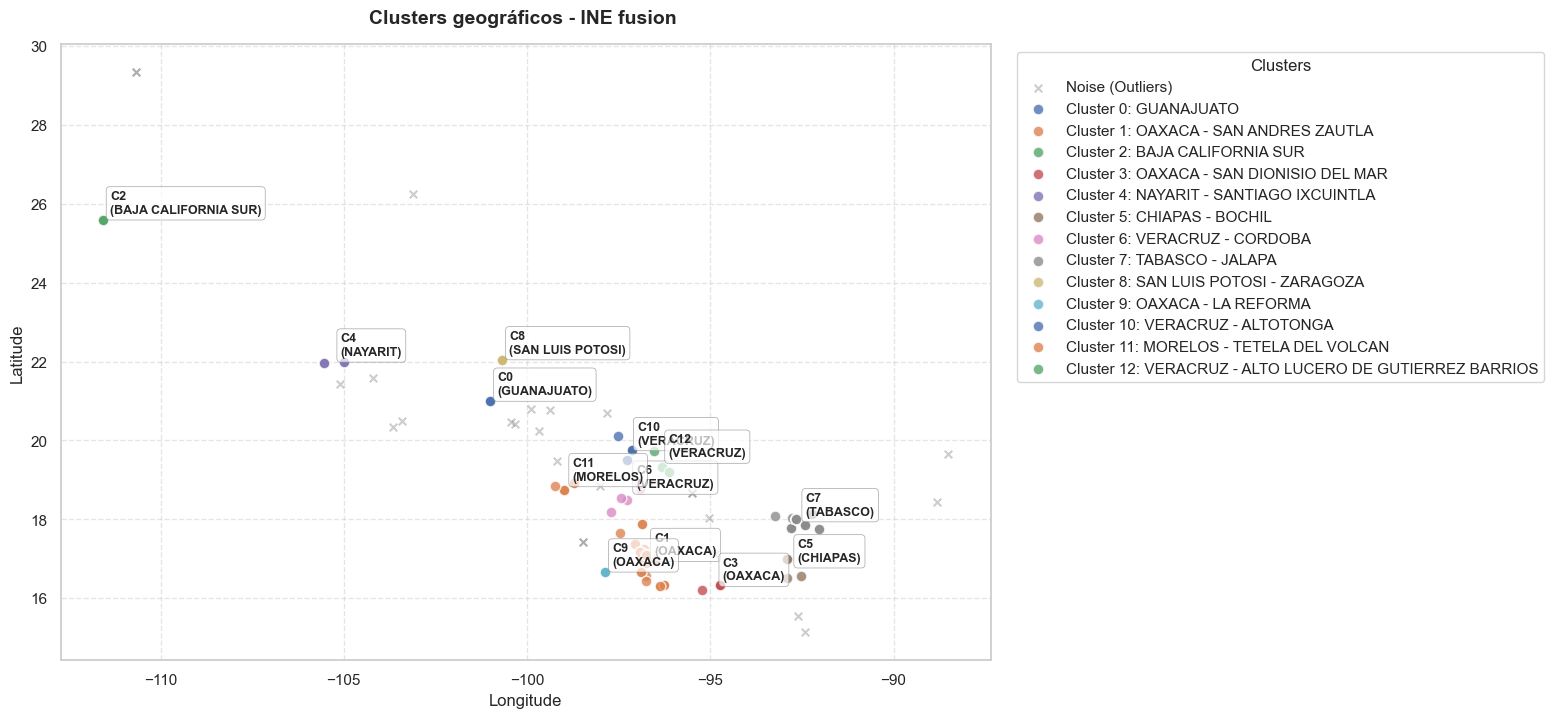

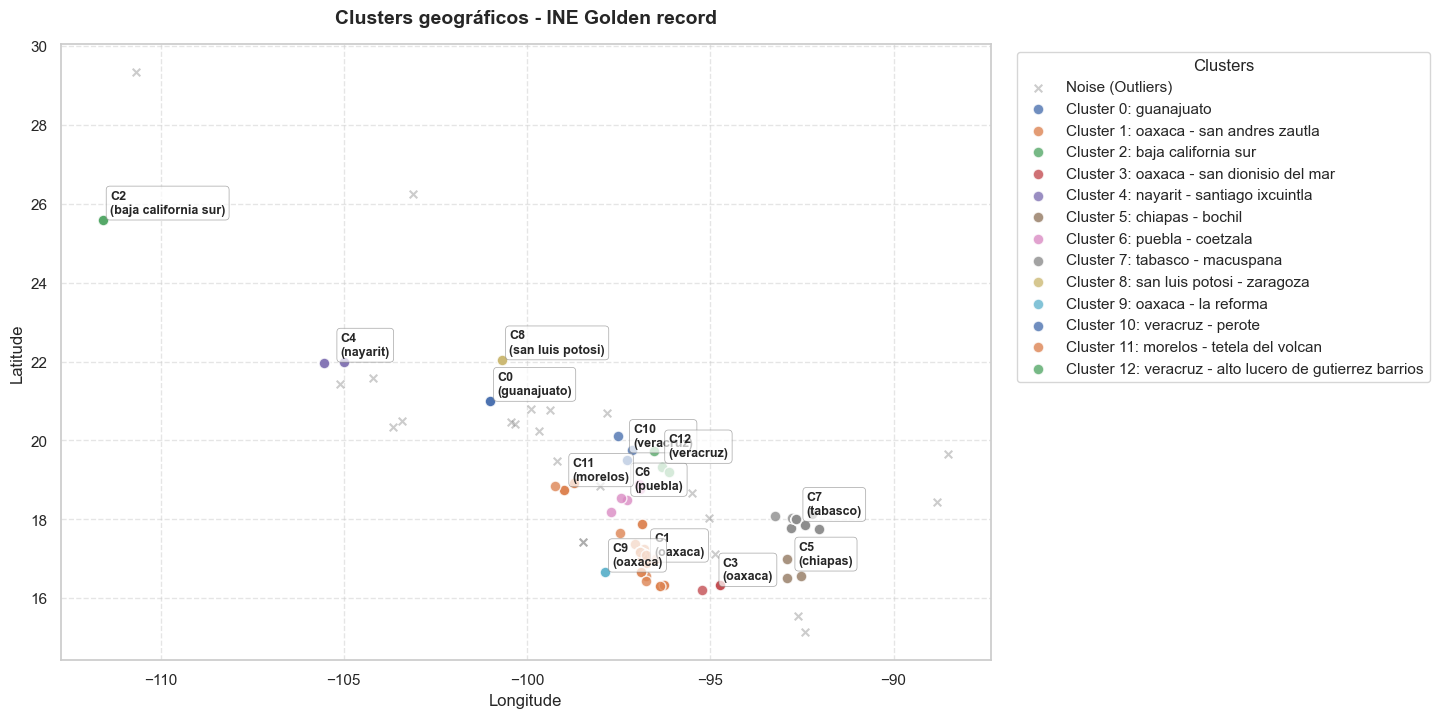

In [103]:

ine_fusion_geoclustering = cluster_geographically(
    ine_fusion_geo, plot_title="Clusters geográficos - INE fusion ", save_plot=True
)
golden_g_geoclustering = cluster_geographically(
    golden_g_geo, plot_title="Clusters geográficos - INE Golden record", save_plot=True)

In [104]:
# bv_fusion_geo = add_coordinates_to_df(bv_fusion)


### Merge

In [105]:
# # ─────────────────────────────────────────────────────────────────────────────
# # FASE L — Ligar: Sorted Neighbourhood Method (SNM)
# # Vinculación municipal entre INE y BANAVIM
# # ─────────────────────────────────────────────────────────────────────────────
# # NOTA: ine_fusion y bv_fusion deben estar cargados (celdas anteriores).
# # El merge NO afirma que sean las mismas personas. Vincula registros del
# # mismo municipio con perfil relacional comparable para construir el
# # perfil estadístico municipal integrado.
# # ─────────────────────────────────────────────────────────────────────────────

# import recordlinkage
# import pandas as pd

# # 1. Indexación por vecindad ordenada sobre municipio
# indexer = recordlinkage.Index()
# indexer.sortedneighbourhood(
#     left_on='municipio',
#     right_on='municipio',
#     window=3          # reducir a 3 si tarda más de 10 min
# )

# candidatos = indexer.index(ine_fusion, bv_fusion)
# print(f'Pares candidatos generados: {len(candidatos):,}')

# # 2. Comparación de campos entre pares candidatos
# comparador = recordlinkage.Compare()
# comparador.string('municipio',     'municipio',
#                   method='jarowinkler', threshold=0.85, label='sim_municipio')
# comparador.string('vinculo_grupo', 'vinculo_grupo',
#                   method='exact',                      label='sim_vinculo')
# comparador.exact ('sexo',          'sexo',              label='sim_sexo')

# # features = comparador.compute(candidatos, ine_fusion, bv_fusion)
# print(f'Comparaciones realizadas: {features.shape}')

# # 3. Score total y tracking de índices originales
# features['score']   = features[['sim_municipio', 'sim_vinculo', 'sim_sexo']].sum(axis=1)
# features['idx_ine'] = features.index.get_level_values(0)
# features['idx_bv']  = features.index.get_level_values(1)

# # 4. Filtrar por umbral (score >= 2.5 sobre 3.0 posible)
# matches = features[features['score'] >= 2.5].copy()
# print(f'Pares vinculados (score >= 2.5): {len(matches):,}')
# print(f'Registros INE con al menos un match: {matches["idx_ine"].nunique():,}')
# print(f'Registros BANAVIM con al menos un match: {matches["idx_bv"].nunique():,}')

# # 5. Enriquecer con datos originales de ambas fuentes
# matches_ine = matches.merge(
#     ine_fusion[['municipio', 'estado', 'sexo', 'vinculo_grupo',
#                 'vinculo_victima', 'fuente']].add_suffix('_ine'),
#     left_on='idx_ine', right_index=True, how='left'
# )
# matches_full = matches_ine.merge(
#     bv_fusion[['municipio', 'estado', 'sexo', 'vinculo_grupo',
#                'edad', 'escolaridad', 'estado_civil',
#                'portaba_arma', 'Droga_Alcohol',
#                'año_banavim', 'fuente']].add_suffix('_bv'),
#     left_on='idx_bv', right_index=True, how='left'
# )

# # 6. Perfil estadístico municipal agregado (producto final)
# perfil_municipal = (
#     matches_full
#     .groupby(['municipio_ine', 'estado_ine', 'vinculo_grupo_ine'])
#     .agg(
#         n_sanciones_ine   = ('idx_ine',        'nunique'),
#         n_casos_banavim   = ('idx_bv',          'nunique'),
#         edad_media_bv     = ('edad_bv',          'mean'),
#         pct_portaba_arma  = ('portaba_arma_bv',
#                              lambda x: (x.str.upper() == 'SI').mean()),
#         pct_alcohol       = ('Droga_Alcohol_bv',
#                              lambda x: (x.str.upper() == 'SI').mean()),
#     )
#     .reset_index()
#     .round(3)
# )

# print(f'\nPerfil municipal generado: {len(perfil_municipal):,} grupos')
# display(perfil_municipal.head(10))

# # # 7. Guardar resultados
# from pathlib import Path
# Path('../Data/fusion_outputs').mkdir(parents=True, exist_ok=True)

# matches_full.to_csv(
#     '../Data/fusion_outputs/matches_snm.csv',
#     index=False, encoding='utf-8-sig'
# )
# perfil_municipal.to_csv(
#     '../Data/fusion_outputs/perfil_municipal_integrado.csv',
#     index=False, encoding='utf-8-sig'
# )

# # print('\nArchivos guardados:')
# # print('  ../Data/fusion_outputs/matches_snm.csv')
# # print('  ../Data/fusion_outputs/perfil_municipal_integrado.csv')